# 05 — Canonical Damage-Size Sensitivity Dataset Generation

This notebook creates a controlled matched dataset for evaluating how restoration behaviour changes as damaged area increases.

## Experiment design

The experiment uses:

- five deterministically selected paintings;
- the canonical `loss_large` mask morphology;
- seven target damage levels:
  - 2%;
  - 4%;
  - 6%;
  - 8%;
  - 10%;
  - 15%;
  - 20%.

Damage percentages are measured relative to the painting-content area recorded during preprocessing.

For each selected painting, one canonical base-mask morphology is retained while its area is adjusted across the target levels. This preserves approximate morphology and spatial placement while varying damage size.

## Responsibilities

This notebook:

1. loads canonical clean-image and mask metadata;
2. deterministically selects the experiment paintings;
3. generates matched masks at every configured damage level;
4. generates corresponding damaged images;
5. records target and realised damage percentages;
6. records deterministic seed and generator provenance;
7. validates dimensions, binary masks, content placement, fill behaviour, and checksums;
8. detects missing, stale, duplicate, and orphaned artifacts;
9. writes one canonical metadata table, one audit table, figures, and experiment reports.

## Scope boundary

This notebook constructs the sensitivity dataset only.

Restoration generation, metric computation, performance curves, statistical analysis, and interpretation are deferred to later notebooks.

In [1]:
from pathlib import Path
import sys


def find_project_root(
    start_path: Path,
) -> Path:
    current_path = start_path.resolve()

    for candidate_path in [
        current_path,
        *current_path.parents,
    ]:
        if (
            (candidate_path / "config").is_dir()
            and (candidate_path / "src").is_dir()
        ):
            return candidate_path

    raise FileNotFoundError(
        "Could not locate the project root. "
        "Expected a parent directory containing "
        "both 'config/' and 'src/'."
    )


PROJECT_ROOT = find_project_root(
    Path.cwd()
)

SRC_DIR = PROJECT_ROOT / "src"

EXPERIMENT_CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "experiment_50_config.yaml"
)


if str(SRC_DIR) not in sys.path:
    sys.path.insert(
        0,
        str(SRC_DIR),
    )


if not SRC_DIR.exists():
    raise FileNotFoundError(
        "Source directory does not exist: "
        f"{SRC_DIR}"
    )


if not EXPERIMENT_CONFIG_PATH.exists():
    raise FileNotFoundError(
        "Experiment configuration does not exist: "
        f"{EXPERIMENT_CONFIG_PATH}"
    )


print("Environment configured")
print("----------------------")
print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)
print(
    "Experiment configuration:",
    EXPERIMENT_CONFIG_PATH,
)

Environment configured
----------------------
Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source directory: D:\Masters\FH\Thesis\painting-restoration-eval\src
Experiment configuration: D:\Masters\FH\Thesis\painting-restoration-eval\config\experiment_50_config.yaml


In [2]:
import json
import shutil
from datetime import datetime, timezone
from textwrap import dedent

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display
from PIL import Image

from restoration_eval.damage_sensitivity import (
    DEFAULT_BASE_MASK_TYPES,
    DEFAULT_TARGET_PERCENTAGES,
    GENERATOR_NAME,
    GENERATOR_VERSION,
    audit_damage_size_sensitivity_inventory,
    create_damage_size_sensitivity_dataset,
    validate_damage_size_sensitivity_dataset,
)


with EXPERIMENT_CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as configuration_file:
    experiment_config = yaml.safe_load(
        configuration_file
    )


if not isinstance(
    experiment_config,
    dict,
):
    raise ValueError(
        "Experiment configuration must contain "
        "a YAML mapping."
    )


required_config_sections = [
    "experiment",
    "paths",
    "dataset",
    "preprocessing",
]


missing_config_sections = [
    section_name
    for section_name in required_config_sections
    if section_name not in experiment_config
]


if missing_config_sections:
    raise ValueError(
        "Configuration is missing required sections: "
        f"{missing_config_sections}"
    )


config_version = str(
    experiment_config.get(
        "config_version",
        "unversioned",
    )
)

experiment_section = experiment_config[
    "experiment"
]

paths_config = experiment_config[
    "paths"
]

dataset_config = experiment_config[
    "dataset"
]

preprocessing_config = experiment_config[
    "preprocessing"
]

sensitivity_config = experiment_config.get(
    "damage_size_sensitivity",
    {},
)


experiment_name = str(
    experiment_section.get(
        "name",
        "unnamed_experiment",
    )
)

experiment_version = str(
    experiment_section.get(
        "version",
        "unversioned",
    )
)


def resolve_project_path(
    path_value: str | Path,
) -> Path:
    resolved_path = Path(
        path_value
    )

    if resolved_path.is_absolute():
        return resolved_path

    return PROJECT_ROOT / resolved_path


processed_metadata_dir = (
    PROJECT_ROOT
    / paths_config[
        "processed_metadata_dir"
    ]
)

processed_metadata_path = (
    processed_metadata_dir
    / "metadata_processed_clean.csv"
)

mask_metadata_path = (
    processed_metadata_dir
    / "metadata_masks.csv"
)

sensitivity_metadata_path = (
    processed_metadata_dir
    / "metadata_damage_size_sensitivity.csv"
)


sensitivity_mask_dir = resolve_project_path(
    sensitivity_config.get(
        "mask_dir",
        (
            "data/processed/masks/"
            "damage_size_sensitivity"
        ),
    )
)

sensitivity_damaged_dir = resolve_project_path(
    sensitivity_config.get(
        "damaged_dir",
        (
            "data/processed/damaged/"
            "damage_size_sensitivity"
        ),
    )
)


sensitivity_output_dir = (
    PROJECT_ROOT
    / "outputs"
    / "05_damage_size_sensitivity"
)

sensitivity_figure_dir = (
    PROJECT_ROOT
    / paths_config["figures_dir"]
    / "damage_size_sensitivity"
)

report_output_dir = (
    PROJECT_ROOT
    / paths_config["reports_dir"]
)


temporary_test_dir = (
    sensitivity_output_dir
    / "tmp_generation_test"
)

temporary_test_mask_dir = (
    temporary_test_dir
    / "masks"
)

temporary_test_damaged_dir = (
    temporary_test_dir
    / "damaged"
)


sensitivity_audit_path = (
    sensitivity_output_dir
    / "damage_size_sensitivity_audit.csv"
)

sensitivity_manifest_path = (
    report_output_dir
    / "damage_size_sensitivity_manifest.json"
)

sensitivity_report_path = (
    report_output_dir
    / "damage_size_sensitivity_report.md"
)


target_percentages = tuple(
    float(value)
    for value in sensitivity_config.get(
        "target_percentages",
        DEFAULT_TARGET_PERCENTAGES,
    )
)

base_mask_types = tuple(
    str(value)
    for value in sensitivity_config.get(
        "base_mask_types",
        DEFAULT_BASE_MASK_TYPES,
    )
)

expected_painting_count = int(
    sensitivity_config.get(
        "expected_painting_count",
        5,
    )
)

global_seed = int(
    sensitivity_config.get(
        "global_seed",
        20260505,
    )
)

maximum_percentage_error = float(
    sensitivity_config.get(
        "maximum_percentage_error",
        0.50,
    )
)

damage_fill_strategy = str(
    sensitivity_config.get(
        "fill_strategy",
        "constant_rgb",
    )
)

damage_fill_color = tuple(
    int(channel_value)
    for channel_value in sensitivity_config.get(
        "fill_color",
        [255, 255, 255],
    )
)

target_size = int(
    preprocessing_config.get(
        "output_size",
        experiment_section.get(
            "image_size",
            768,
        ),
    )
)


expected_base_mask_type_count = len(
    base_mask_types
)

expected_target_level_count = len(
    target_percentages
)

expected_case_count = (
    expected_painting_count
    * expected_base_mask_type_count
    * expected_target_level_count
)


for output_directory in [
    processed_metadata_dir,
    sensitivity_mask_dir,
    sensitivity_damaged_dir,
    sensitivity_output_dir,
    sensitivity_figure_dir,
    report_output_dir,
]:
    output_directory.mkdir(
        parents=True,
        exist_ok=True,
    )


if expected_painting_count <= 0:
    raise ValueError(
        "Expected painting count must be positive."
    )


if not target_percentages:
    raise ValueError(
        "At least one target damage percentage "
        "must be configured."
    )


if len(
    set(target_percentages)
) != len(target_percentages):
    raise ValueError(
        "Target percentages must be unique."
    )


if (
    tuple(
        sorted(target_percentages)
    )
    != target_percentages
):
    raise ValueError(
        "Target percentages must be sorted "
        "in ascending order."
    )


if any(
    target_percentage <= 0
    or target_percentage >= 100
    for target_percentage in target_percentages
):
    raise ValueError(
        "Target percentages must lie strictly "
        "between 0 and 100."
    )


if len(
    set(base_mask_types)
) != len(base_mask_types):
    raise ValueError(
        "Base mask types must be unique."
    )


if base_mask_types != (
    "loss_large",
):
    raise ValueError(
        "Notebook 05 currently requires exactly "
        "one base mask type: 'loss_large'."
    )


if len(damage_fill_color) != 3:
    raise ValueError(
        "Damage-fill colour must contain exactly "
        "three RGB values."
    )


if any(
    channel_value < 0
    or channel_value > 255
    for channel_value in damage_fill_color
):
    raise ValueError(
        "Damage-fill RGB values must lie "
        "between 0 and 255."
    )


if expected_case_count != 35:
    raise ValueError(
        "Current Notebook 05 design must produce "
        "exactly 35 cases: "
        f"observed={expected_case_count}"
    )


print("Configuration loaded")
print("--------------------")
print("Config version:", config_version)
print("Experiment:", experiment_name)
print(
    "Experiment version:",
    experiment_version,
)
print("Generator:", GENERATOR_NAME)
print(
    "Generator version:",
    GENERATOR_VERSION,
)
print(
    "Selected painting count:",
    expected_painting_count,
)
print(
    "Base mask types:",
    base_mask_types,
)
print(
    "Target percentages:",
    target_percentages,
)
print("Global seed:", global_seed)
print(
    "Maximum percentage error:",
    maximum_percentage_error,
)
print(
    "Expected sensitivity cases:",
    expected_case_count,
)
print(
    "Damage-fill strategy:",
    damage_fill_strategy,
)
print(
    "Damage-fill colour:",
    damage_fill_color,
)
print("Target image size:", target_size)


print("\nCanonical inputs")
print("----------------")
print(
    "Processed metadata:",
    processed_metadata_path,
)
print(
    "Mask metadata:",
    mask_metadata_path,
)


print("\nCanonical outputs")
print("-----------------")
print(
    "Sensitivity masks:",
    sensitivity_mask_dir,
)
print(
    "Sensitivity damaged images:",
    sensitivity_damaged_dir,
)
print(
    "Sensitivity metadata:",
    sensitivity_metadata_path,
)
print(
    "Audit:",
    sensitivity_audit_path,
)
print(
    "Figures:",
    sensitivity_figure_dir,
)
print(
    "Manifest:",
    sensitivity_manifest_path,
)
print(
    "Report:",
    sensitivity_report_path,
)

Configuration loaded
--------------------
Config version: 1.1.0
Experiment: painting_restoration_50_subset
Experiment version: 1.0.0
Generator: damage_size_sensitivity
Generator version: 1.1.0
Selected painting count: 5
Base mask types: ('loss_large',)
Target percentages: (2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0)
Global seed: 20260505
Maximum percentage error: 0.5
Expected sensitivity cases: 35
Damage-fill strategy: constant_rgb
Damage-fill colour: (255, 255, 255)
Target image size: 768

Canonical inputs
----------------
Processed metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_processed_clean.csv
Mask metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_masks.csv

Canonical outputs
-----------------
Sensitivity masks: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masks\damage_size_sensitivity
Sensitivity damaged images: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\damaged\damag

In [4]:
# Load and validate canonical source metadata

required_input_paths = [
    processed_metadata_path,
    mask_metadata_path,
]


missing_input_paths = [
    input_path
    for input_path in required_input_paths
    if not input_path.exists()
]


if missing_input_paths:
    raise FileNotFoundError(
        "Required Notebook 05 inputs are missing: "
        f"{missing_input_paths}"
    )


processed_metadata_df = pd.read_csv(
    processed_metadata_path
)

mask_metadata_df = pd.read_csv(
    mask_metadata_path
)


required_processed_columns = [
    "painting_id",
    "processed_filename",
    "processed_path",
    "processed_width",
    "processed_height",
    "content_width",
    "content_height",
]

required_mask_columns = [
    "case_id",
    "painting_id",
    "mask_id",
    "mask_type",
    "mask_filename",
    "mask_path",
    "actual_mask_area_pixels",
    "actual_mask_area_percentage_content",
    "actual_mask_area_percentage_full",
]


missing_processed_columns = [
    column_name
    for column_name in required_processed_columns
    if column_name
    not in processed_metadata_df.columns
]

missing_mask_columns = [
    column_name
    for column_name in required_mask_columns
    if column_name
    not in mask_metadata_df.columns
]


if missing_processed_columns:
    raise ValueError(
        "Processed metadata is missing required "
        "columns: "
        f"{missing_processed_columns}"
    )


if missing_mask_columns:
    raise ValueError(
        "Mask metadata is missing required columns: "
        f"{missing_mask_columns}"
    )


processed_metadata_df[
    "painting_id"
] = (
    processed_metadata_df[
        "painting_id"
    ]
    .astype(str)
)

mask_metadata_df[
    "painting_id"
] = (
    mask_metadata_df[
        "painting_id"
    ]
    .astype(str)
)

mask_metadata_df[
    "mask_id"
] = (
    mask_metadata_df[
        "mask_id"
    ]
    .astype(str)
)

mask_metadata_df[
    "mask_type"
] = (
    mask_metadata_df[
        "mask_type"
    ]
    .astype(str)
)


duplicate_processed_rows = (
    processed_metadata_df.loc[
        processed_metadata_df[
            "painting_id"
        ]
        .duplicated(
            keep=False
        )
    ]
    .copy()
)


duplicate_mask_id_rows = (
    mask_metadata_df.loc[
        mask_metadata_df[
            "mask_id"
        ]
        .duplicated(
            keep=False
        )
    ]
    .copy()
)


if not duplicate_processed_rows.empty:
    display(
        duplicate_processed_rows
    )

    raise ValueError(
        "Processed metadata contains duplicate "
        "painting IDs."
    )


if not duplicate_mask_id_rows.empty:
    display(
        duplicate_mask_id_rows
    )

    raise ValueError(
        "Mask metadata contains duplicate mask IDs."
    )


processed_dimension_failure_df = (
    processed_metadata_df.loc[
        (
            pd.to_numeric(
                processed_metadata_df[
                    "processed_width"
                ],
                errors="coerce",
            )
            != target_size
        )
        |
        (
            pd.to_numeric(
                processed_metadata_df[
                    "processed_height"
                ],
                errors="coerce",
            )
            != target_size
        )
    ]
    .copy()
)


available_mask_types = sorted(
    mask_metadata_df[
        "mask_type"
    ]
    .dropna()
    .unique()
    .tolist()
)


missing_base_mask_types = sorted(
    set(base_mask_types)
    - set(available_mask_types)
)


eligible_base_mask_df = (
    mask_metadata_df.loc[
        mask_metadata_df[
            "mask_type"
        ]
        .isin(base_mask_types)
    ]
    .copy()
)


duplicate_base_mask_rows = (
    eligible_base_mask_df.loc[
        eligible_base_mask_df.duplicated(
            subset=[
                "painting_id",
                "mask_type",
            ],
            keep=False,
        )
    ]
    .copy()
)


eligible_painting_ids = sorted(
    set(
        processed_metadata_df[
            "painting_id"
        ]
    )
    & set(
        eligible_base_mask_df[
            "painting_id"
        ]
    )
)


if len(
    eligible_painting_ids
) < expected_painting_count:
    raise ValueError(
        "There are not enough eligible paintings "
        "with the configured base mask types: "
        f"available={len(eligible_painting_ids)}, "
        f"required={expected_painting_count}"
    )


eligible_processed_metadata_df = (
    processed_metadata_df.loc[
        processed_metadata_df[
            "painting_id"
        ]
        .isin(
            eligible_painting_ids
        )
    ]
    .sort_values(
        "painting_id",
        kind="stable",
    )
    .reset_index(drop=True)
)


sensitivity_processed_metadata_df = (
    eligible_processed_metadata_df
    .sample(
        n=expected_painting_count,
        random_state=global_seed,
        replace=False,
    )
    .sort_values(
        "painting_id",
        kind="stable",
    )
    .reset_index(drop=True)
)


selected_painting_ids = set(
    sensitivity_processed_metadata_df[
        "painting_id"
    ]
)


selected_base_mask_metadata_df = (
    eligible_base_mask_df.loc[
        eligible_base_mask_df[
            "painting_id"
        ]
        .isin(
            selected_painting_ids
        )
    ]
    .sort_values(
        [
            "painting_id",
            "mask_type",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


expected_base_mask_rows = (
    expected_painting_count
    * expected_base_mask_type_count
)


missing_clean_file_records = []


for processed_row in (
    sensitivity_processed_metadata_df
    .itertuples(
        index=False
    )
):
    clean_image_path = Path(
        str(
            processed_row.processed_path
        )
    )

    if not clean_image_path.is_absolute():
        clean_image_path = (
            PROJECT_ROOT
            / clean_image_path
        )

    if not clean_image_path.exists():
        missing_clean_file_records.append(
            {
                "painting_id": str(
                    processed_row.painting_id
                ),
                "clean_image_path": str(
                    clean_image_path
                ),
            }
        )


missing_base_mask_file_records = []


for mask_row in (
    selected_base_mask_metadata_df
    .itertuples(
        index=False
    )
):
    base_mask_path = Path(
        str(
            mask_row.mask_path
        )
    )

    if not base_mask_path.is_absolute():
        base_mask_path = (
            PROJECT_ROOT
            / base_mask_path
        )

    if not base_mask_path.exists():
        missing_base_mask_file_records.append(
            {
                "painting_id": str(
                    mask_row.painting_id
                ),
                "mask_type": str(
                    mask_row.mask_type
                ),
                "mask_path": str(
                    base_mask_path
                ),
            }
        )


source_gate_summary_df = pd.DataFrame(
    [
        {
            "check": "processed_metadata_rows",
            "observed": len(
                processed_metadata_df
            ),
            "expected": int(
                dataset_config.get(
                    "total_paintings",
                    len(
                        processed_metadata_df
                    ),
                )
            ),
            "passed": (
                len(processed_metadata_df)
                == int(
                    dataset_config.get(
                        "total_paintings",
                        len(
                            processed_metadata_df
                        ),
                    )
                )
            ),
        },
        {
            "check": "processed_dimensions",
            "observed": len(
                processed_dimension_failure_df
            ),
            "expected": 0,
            "passed": (
                processed_dimension_failure_df.empty
            ),
        },
        {
            "check": "missing_base_mask_types",
            "observed": len(
                missing_base_mask_types
            ),
            "expected": 0,
            "passed": (
                not missing_base_mask_types
            ),
        },
        {
            "check": "duplicate_base_mask_cases",
            "observed": len(
                duplicate_base_mask_rows
            ),
            "expected": 0,
            "passed": (
                duplicate_base_mask_rows.empty
            ),
        },
        {
            "check": "selected_paintings",
            "observed": len(
                sensitivity_processed_metadata_df
            ),
            "expected": expected_painting_count,
            "passed": (
                len(
                    sensitivity_processed_metadata_df
                )
                == expected_painting_count
            ),
        },
        {
            "check": "selected_base_masks",
            "observed": len(
                selected_base_mask_metadata_df
            ),
            "expected": expected_base_mask_rows,
            "passed": (
                len(
                    selected_base_mask_metadata_df
                )
                == expected_base_mask_rows
            ),
        },
        {
            "check": "missing_clean_files",
            "observed": len(
                missing_clean_file_records
            ),
            "expected": 0,
            "passed": (
                not missing_clean_file_records
            ),
        },
        {
            "check": "missing_base_mask_files",
            "observed": len(
                missing_base_mask_file_records
            ),
            "expected": 0,
            "passed": (
                not missing_base_mask_file_records
            ),
        },
    ]
)


selected_display_columns = [
    column_name
    for column_name in [
        "painting_id",
        "title",
        "artist",
        "category",
        "style_group",
        "genre",
        "processed_filename",
        "processed_path",
    ]
    if column_name
    in sensitivity_processed_metadata_df.columns
]


print("Selected sensitivity paintings")
print("------------------------------")

display(
    sensitivity_processed_metadata_df[
        selected_display_columns
    ]
)


print("\nCanonical source gate")
print("---------------------")

display(
    source_gate_summary_df
)


if not processed_dimension_failure_df.empty:
    print(
        "\nProcessed dimension failures"
    )

    display(
        processed_dimension_failure_df
    )


if not duplicate_base_mask_rows.empty:
    print(
        "\nDuplicate base-mask cases"
    )

    display(
        duplicate_base_mask_rows
    )


if missing_clean_file_records:
    print(
        "\nMissing clean-image files"
    )

    display(
        pd.DataFrame(
            missing_clean_file_records
        )
    )


if missing_base_mask_file_records:
    print(
        "\nMissing base-mask files"
    )

    display(
        pd.DataFrame(
            missing_base_mask_file_records
        )
    )


failed_source_gate_df = (
    source_gate_summary_df.loc[
        ~source_gate_summary_df[
            "passed"
        ].astype(bool)
    ]
    .copy()
)


if not failed_source_gate_df.empty:
    display(
        failed_source_gate_df
    )

    raise RuntimeError(
        "Canonical Notebook 05 source gate failed."
    )


print(
    "\nCanonical Notebook 05 source gate passed."
)

Selected sensitivity paintings
------------------------------


,painting_id,title,artist,category,processed_filename,processed_path
0,p001,Juan de Pareja,Diego Velázquez,portrait_figure,p001_clean.png,data/processed/clean/p001_clean.png
1,p018,Classical Landscape with Figures,Henri Mauperché,landscape_natural,p018_clean.png,data/processed/clean/p018_clean.png
2,p026,View of a Village along a River,attributed to Jan Brueghel I,architecture_structured,p026_clean.png,data/processed/clean/p026_clean.png
3,p039,Painting with Troika,Wassily Kandinsky,abstraction_surrealism,p039_clean.png,data/processed/clean/p039_clean.png
4,p043,The Card Players,Paul Cézanne,high_texture_brushwork,p043_clean.png,data/processed/clean/p043_clean.png



Canonical source gate
---------------------


,check,observed,expected,passed
0,processed_metadata_rows,50,50,True
1,processed_dimensions,0,0,True
2,missing_base_mask_types,0,0,True
3,duplicate_base_mask_cases,0,0,True
4,selected_paintings,5,5,True
5,selected_base_masks,5,5,True
6,missing_clean_files,0,0,True
7,missing_base_mask_files,0,0,True



Canonical Notebook 05 source gate passed.


In [5]:
# Construct the expected 35-case sensitivity manifest

expected_case_records = []


for painting_id in sorted(
    sensitivity_processed_metadata_df[
        "painting_id"
    ]
    .astype(str)
    .tolist()
):
    for base_mask_type in base_mask_types:
        for target_percentage in target_percentages:
            target_percentage = float(
                target_percentage
            )

            if target_percentage.is_integer():
                percentage_token = (
                    f"{int(target_percentage):02d}pct"
                )
            else:
                percentage_token = (
                    f"{target_percentage:.2f}"
                    .rstrip("0")
                    .rstrip(".")
                    .replace(".", "p")
                    + "pct"
                )

            case_id = (
                f"{painting_id}"
                f"__{base_mask_type}"
                f"__size_{percentage_token}"
            )

            expected_case_records.append(
                {
                    "case_id": case_id,
                    "painting_id": painting_id,
                    "base_mask_type": (
                        base_mask_type
                    ),
                    "target_percentage_content": (
                        target_percentage
                    ),
                    "deterministic_seed_policy": (
                        "sha256(global_seed|"
                        "painting_id|base_mask_type)"
                    ),
                    "global_seed": global_seed,
                }
            )


expected_case_manifest_df = pd.DataFrame(
    expected_case_records
)


if (
    len(expected_case_manifest_df)
    != expected_case_count
):
    raise RuntimeError(
        "Expected sensitivity-case count is invalid: "
        f"observed={len(expected_case_manifest_df)}, "
        f"expected={expected_case_count}"
    )


if expected_case_manifest_df[
    "case_id"
].astype(str).duplicated().any():
    duplicate_expected_cases_df = (
        expected_case_manifest_df.loc[
            expected_case_manifest_df[
                "case_id"
            ]
            .astype(str)
            .duplicated(
                keep=False
            )
        ]
        .copy()
    )

    display(
        duplicate_expected_cases_df
    )

    raise RuntimeError(
        "Expected sensitivity manifest contains "
        "duplicate case IDs."
    )


expected_case_distribution_df = (
    expected_case_manifest_df
    .groupby(
        [
            "base_mask_type",
            "target_percentage_content",
        ],
        sort=True,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
    )
    .reset_index()
)


invalid_expected_distribution_df = (
    expected_case_distribution_df.loc[
        (
            expected_case_distribution_df[
                "case_count"
            ]
            != expected_painting_count
        )
        |
        (
            expected_case_distribution_df[
                "painting_count"
            ]
            != expected_painting_count
        )
    ]
    .copy()
)


expected_case_gate_df = pd.DataFrame(
    [
        {
            "check": "expected_case_count",
            "observed": len(
                expected_case_manifest_df
            ),
            "expected": expected_case_count,
            "passed": (
                len(
                    expected_case_manifest_df
                )
                == expected_case_count
            ),
        },
        {
            "check": "unique_case_ids",
            "observed": (
                expected_case_manifest_df[
                    "case_id"
                ]
                .astype(str)
                .nunique()
            ),
            "expected": expected_case_count,
            "passed": (
                expected_case_manifest_df[
                    "case_id"
                ]
                .astype(str)
                .nunique()
                == expected_case_count
            ),
        },
        {
            "check": "painting_count",
            "observed": (
                expected_case_manifest_df[
                    "painting_id"
                ]
                .astype(str)
                .nunique()
            ),
            "expected": expected_painting_count,
            "passed": (
                expected_case_manifest_df[
                    "painting_id"
                ]
                .astype(str)
                .nunique()
                == expected_painting_count
            ),
        },
        {
            "check": "base_mask_type_count",
            "observed": (
                expected_case_manifest_df[
                    "base_mask_type"
                ]
                .astype(str)
                .nunique()
            ),
            "expected": (
                expected_base_mask_type_count
            ),
            "passed": (
                expected_case_manifest_df[
                    "base_mask_type"
                ]
                .astype(str)
                .nunique()
                == expected_base_mask_type_count
            ),
        },
        {
            "check": "target_level_count",
            "observed": (
                expected_case_manifest_df[
                    "target_percentage_content"
                ]
                .astype(float)
                .nunique()
            ),
            "expected": expected_target_level_count,
            "passed": (
                expected_case_manifest_df[
                    "target_percentage_content"
                ]
                .astype(float)
                .nunique()
                == expected_target_level_count
            ),
        },
        {
            "check": "invalid_distribution_rows",
            "observed": len(
                invalid_expected_distribution_df
            ),
            "expected": 0,
            "passed": (
                invalid_expected_distribution_df.empty
            ),
        },
    ]
)


print("Expected sensitivity-case distribution")
print("--------------------------------------")

display(
    expected_case_distribution_df
)


print("\nExpected-case gate")
print("------------------")

display(
    expected_case_gate_df
)


failed_expected_case_gate_df = (
    expected_case_gate_df.loc[
        ~expected_case_gate_df[
            "passed"
        ].astype(bool)
    ]
    .copy()
)


if not failed_expected_case_gate_df.empty:
    display(
        failed_expected_case_gate_df
    )

    raise RuntimeError(
        "Expected sensitivity-case manifest "
        "validation failed."
    )


print(
    "\nExpected 35-case sensitivity manifest passed."
)

Expected sensitivity-case distribution
--------------------------------------


,base_mask_type,target_percentage_content,case_count,painting_count
0,loss_large,2.0,5,5
1,loss_large,4.0,5,5
2,loss_large,6.0,5,5
3,loss_large,8.0,5,5
4,loss_large,10.0,5,5
5,loss_large,15.0,5,5
6,loss_large,20.0,5,5



Expected-case gate
------------------


,check,observed,expected,passed
0,expected_case_count,35,35,True
1,unique_case_ids,35,35,True
2,painting_count,5,5,True
3,base_mask_type_count,1,1,True
4,target_level_count,7,7,True
5,invalid_distribution_rows,0,0,True



Expected 35-case sensitivity manifest passed.


In [6]:
# Run a one-painting, seven-level sensitivity-generation test

if temporary_test_dir.exists():
    shutil.rmtree(
        temporary_test_dir
    )


temporary_test_mask_dir.mkdir(
    parents=True,
    exist_ok=True,
)

temporary_test_damaged_dir.mkdir(
    parents=True,
    exist_ok=True,
)


test_painting_id = sorted(
    sensitivity_processed_metadata_df[
        "painting_id"
    ]
    .astype(str)
    .tolist()
)[0]


test_processed_metadata_df = (
    sensitivity_processed_metadata_df.loc[
        sensitivity_processed_metadata_df[
            "painting_id"
        ]
        .astype(str)
        == test_painting_id
    ]
    .copy()
)


test_mask_metadata_df = (
    selected_base_mask_metadata_df.loc[
        selected_base_mask_metadata_df[
            "painting_id"
        ]
        .astype(str)
        == test_painting_id
    ]
    .copy()
)


expected_test_case_count = (
    expected_base_mask_type_count
    * expected_target_level_count
)


if len(test_processed_metadata_df) != 1:
    raise RuntimeError(
        "The one-painting test requires exactly "
        "one processed-metadata row."
    )


if (
    len(test_mask_metadata_df)
    != expected_base_mask_type_count
):
    raise RuntimeError(
        "The one-painting test contains an invalid "
        "number of base-mask rows: "
        f"observed={len(test_mask_metadata_df)}, "
        f"expected={expected_base_mask_type_count}"
    )


observed_test_base_mask_types = set(
    test_mask_metadata_df[
        "mask_type"
    ]
    .astype(str)
)


if observed_test_base_mask_types != set(
    base_mask_types
):
    raise RuntimeError(
        "The one-painting test does not contain "
        "the configured base-mask inventory: "
        f"observed={sorted(observed_test_base_mask_types)}, "
        f"expected={sorted(base_mask_types)}"
    )


print("One-painting test configuration")
print("-------------------------------")
print("Painting:", test_painting_id)
print(
    "Base mask types:",
    base_mask_types,
)
print(
    "Target percentages:",
    target_percentages,
)
print(
    "Expected test cases:",
    expected_test_case_count,
)


test_generation_started_at_utc = (
    datetime.now(
        timezone.utc
    ).isoformat()
)


test_sensitivity_metadata_df = (
    create_damage_size_sensitivity_dataset(
        processed_metadata=(
            test_processed_metadata_df
        ),
        mask_metadata=(
            test_mask_metadata_df
        ),
        target_percentages=(
            target_percentages
        ),
        output_mask_dir=(
            temporary_test_mask_dir
        ),
        output_damaged_dir=(
            temporary_test_damaged_dir
        ),
        project_root=PROJECT_ROOT,
        base_mask_types=(
            base_mask_types
        ),
        fill_color=(
            damage_fill_color
        ),
        fill_strategy=(
            damage_fill_strategy
        ),
        global_seed=global_seed,
        overwrite=True,
        compute_checksums=True,
    )
)


test_generation_completed_at_utc = (
    datetime.now(
        timezone.utc
    ).isoformat()
)


print(
    "\nTest generation started:",
    test_generation_started_at_utc,
)

print(
    "Test generation completed:",
    test_generation_completed_at_utc,
)

print(
    "Generated test rows:",
    len(test_sensitivity_metadata_df),
)


if test_sensitivity_metadata_df.empty:
    raise RuntimeError(
        "One-painting sensitivity generation "
        "returned no metadata rows."
    )


required_test_generation_columns = [
    "case_id",
    "painting_id",
    "base_mask_type",
    "target_percentage_content",
    "realised_percentage_content",
    "absolute_percentage_error_content",
    "deterministic_seed",
    "global_seed",
    "sensitivity_mask_path",
    "damaged_path",
    "status",
]


missing_test_generation_columns = [
    column_name
    for column_name in required_test_generation_columns
    if column_name
    not in test_sensitivity_metadata_df.columns
]


if missing_test_generation_columns:
    raise RuntimeError(
        "One-painting sensitivity metadata is "
        "missing required columns: "
        f"{missing_test_generation_columns}"
    )


test_display_columns = [
    column_name
    for column_name in [
        "case_id",
        "painting_id",
        "base_mask_type",
        "target_percentage_content",
        "realised_percentage_content",
        "absolute_percentage_error_content",
        "absolute_pixel_error",
        "scale_factor",
        "deterministic_seed",
        "generation_action",
        "status",
        "issue",
    ]
    if column_name
    in test_sensitivity_metadata_df.columns
]


display(
    test_sensitivity_metadata_df[
        test_display_columns
    ]
)


if (
    len(test_sensitivity_metadata_df)
    != expected_test_case_count
):
    raise RuntimeError(
        "One-painting sensitivity generation "
        "produced an invalid number of rows: "
        f"observed={len(test_sensitivity_metadata_df)}, "
        f"expected={expected_test_case_count}"
    )


if test_sensitivity_metadata_df[
    "case_id"
].astype(str).duplicated().any():
    duplicate_test_case_rows_df = (
        test_sensitivity_metadata_df.loc[
            test_sensitivity_metadata_df[
                "case_id"
            ]
            .astype(str)
            .duplicated(
                keep=False
            )
        ]
        .copy()
    )

    display(
        duplicate_test_case_rows_df
    )

    raise RuntimeError(
        "One-painting sensitivity generation "
        "contains duplicate case IDs."
    )


test_generation_error_rows_df = (
    test_sensitivity_metadata_df.loc[
        test_sensitivity_metadata_df[
            "status"
        ]
        .astype(str)
        != "ok"
    ]
    .copy()
)


if not test_generation_error_rows_df.empty:
    display(
        test_generation_error_rows_df
    )

    raise RuntimeError(
        "One-painting sensitivity generation "
        "produced unsuccessful rows."
    )


observed_test_target_percentages = tuple(
    sorted(
        test_sensitivity_metadata_df[
            "target_percentage_content"
        ]
        .astype(float)
        .tolist()
    )
)


expected_repeated_test_targets = tuple(
    sorted(
        target_percentage
        for _ in base_mask_types
        for target_percentage
        in target_percentages
    )
)


if (
    observed_test_target_percentages
    != expected_repeated_test_targets
):
    raise RuntimeError(
        "One-painting sensitivity generation "
        "does not contain the configured targets: "
        f"observed={observed_test_target_percentages}, "
        f"expected={expected_repeated_test_targets}"
    )


if not (
    test_sensitivity_metadata_df[
        "global_seed"
    ]
    .astype(int)
    == global_seed
).all():
    raise RuntimeError(
        "One-painting sensitivity metadata "
        "contains an unexpected global seed."
    )


print(
    "\nOne-painting sensitivity generation passed."
)

One-painting test configuration
-------------------------------
Painting: p001
Base mask types: ('loss_large',)
Target percentages: (2.0, 4.0, 6.0, 8.0, 10.0, 15.0, 20.0)
Expected test cases: 7

Test generation started: 2026-07-24T20:22:00.713171+00:00
Test generation completed: 2026-07-24T20:22:05.030518+00:00
Generated test rows: 7


,case_id,painting_id,base_mask_type,target_percentage_content,realised_percentage_content,absolute_percentage_error_content,absolute_pixel_error,scale_factor,deterministic_seed,generation_action,status,issue
0,p001__loss_large__size_02pct,p001,loss_large,2.0,1.997117,0.002883,15,0.384048,1367668169,generated,ok,
1,p001__loss_large__size_04pct,p001,loss_large,4.0,3.984807,0.015193,77,0.542068,1367668169,generated,ok,
2,p001__loss_large__size_06pct,p001,loss_large,6.0,6.002742,0.002742,14,0.665179,1367668169,generated,ok,
3,p001__loss_large__size_08pct,p001,loss_large,8.0,8.009875,0.009875,50,0.769563,1367668169,generated,ok,
4,p001__loss_large__size_10pct,p001,loss_large,10.0,9.997368,0.002632,13,0.858740,1367668169,generated,ok,
5,p001__loss_large__size_15pct,p001,loss_large,15.0,14.999097,0.000903,5,1.051744,1367668169,generated,ok,
6,p001__loss_large__size_20pct,p001,loss_large,20.0,20.025570,0.025570,130,1.214448,1367668169,generated,ok,



One-painting sensitivity generation passed.


In [7]:
# Validate the one-painting sensitivity-generation test

test_sensitivity_validation_df = (
    validate_damage_size_sensitivity_dataset(
        sensitivity_metadata=(
            test_sensitivity_metadata_df
        ),
        project_root=PROJECT_ROOT,
        verify_checksums=True,
        maximum_percentage_error=(
            maximum_percentage_error
        ),
    )
)


if test_sensitivity_validation_df.empty:
    raise RuntimeError(
        "One-painting validation returned "
        "an empty result."
    )


required_test_validation_columns = [
    "case_id",
    "validation_passed",
    "target_error_valid",
    "outside_mask_preserved",
    "outside_mask_changed_pixels",
    "masked_fill_valid",
    "inside_mask_not_fill_pixels",
    "checksum_valid",
]


missing_test_validation_columns = [
    column_name
    for column_name in required_test_validation_columns
    if column_name
    not in test_sensitivity_validation_df.columns
]


if missing_test_validation_columns:
    raise RuntimeError(
        "One-painting validation is missing "
        "required columns: "
        f"{missing_test_validation_columns}"
    )


test_target_distribution_df = (
    test_sensitivity_metadata_df
    .groupby(
        [
            "base_mask_type",
            "target_percentage_content",
        ],
        sort=True,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
    )
    .reset_index()
)


invalid_test_target_distribution_df = (
    test_target_distribution_df.loc[
        (
            test_target_distribution_df[
                "case_count"
            ]
            != 1
        )
        |
        (
            test_target_distribution_df[
                "painting_count"
            ]
            != 1
        )
    ]
    .copy()
)


test_validation_case_ids = set(
    test_sensitivity_validation_df[
        "case_id"
    ]
    .astype(str)
)


test_generation_case_ids = set(
    test_sensitivity_metadata_df[
        "case_id"
    ]
    .astype(str)
)


test_validation_summary_df = pd.DataFrame(
    [
        {
            "check": "generated_test_rows",
            "observed": len(
                test_sensitivity_metadata_df
            ),
            "expected": expected_test_case_count,
            "passed": (
                len(
                    test_sensitivity_metadata_df
                )
                == expected_test_case_count
            ),
        },
        {
            "check": "validation_rows",
            "observed": len(
                test_sensitivity_validation_df
            ),
            "expected": expected_test_case_count,
            "passed": (
                len(
                    test_sensitivity_validation_df
                )
                == expected_test_case_count
            ),
        },
        {
            "check": "validation_case_coverage",
            "observed": len(
                test_validation_case_ids
            ),
            "expected": len(
                test_generation_case_ids
            ),
            "passed": (
                test_validation_case_ids
                == test_generation_case_ids
            ),
        },
        {
            "check": "target_distribution",
            "observed": len(
                invalid_test_target_distribution_df
            ),
            "expected": 0,
            "passed": (
                invalid_test_target_distribution_df.empty
            ),
        },
        {
            "check": "validation_failures",
            "observed": int(
                (
                    ~test_sensitivity_validation_df[
                        "validation_passed"
                    ]
                    .astype(bool)
                )
                .sum()
            ),
            "expected": 0,
            "passed": bool(
                test_sensitivity_validation_df[
                    "validation_passed"
                ]
                .astype(bool)
                .all()
            ),
        },
        {
            "check": "target_error_failures",
            "observed": int(
                (
                    ~test_sensitivity_validation_df[
                        "target_error_valid"
                    ]
                    .astype(bool)
                )
                .sum()
            ),
            "expected": 0,
            "passed": bool(
                test_sensitivity_validation_df[
                    "target_error_valid"
                ]
                .astype(bool)
                .all()
            ),
        },
        {
            "check": "outside_mask_changes",
            "observed": int(
                pd.to_numeric(
                    test_sensitivity_validation_df[
                        "outside_mask_changed_pixels"
                    ],
                    errors="coerce",
                )
                .fillna(0)
                .sum()
            ),
            "expected": 0,
            "passed": bool(
                test_sensitivity_validation_df[
                    "outside_mask_preserved"
                ]
                .astype(bool)
                .all()
            ),
        },
        {
            "check": "inside_mask_fill_failures",
            "observed": int(
                pd.to_numeric(
                    test_sensitivity_validation_df[
                        "inside_mask_not_fill_pixels"
                    ],
                    errors="coerce",
                )
                .fillna(0)
                .sum()
            ),
            "expected": 0,
            "passed": bool(
                test_sensitivity_validation_df[
                    "masked_fill_valid"
                ]
                .astype(bool)
                .all()
            ),
        },
        {
            "check": "checksum_failures",
            "observed": int(
                (
                    ~test_sensitivity_validation_df[
                        "checksum_valid"
                    ]
                    .astype(bool)
                )
                .sum()
            ),
            "expected": 0,
            "passed": bool(
                test_sensitivity_validation_df[
                    "checksum_valid"
                ]
                .astype(bool)
                .all()
            ),
        },
    ]
)


print("One-painting validation summary")
print("-------------------------------")

display(
    test_validation_summary_df
)


print("\nPer-target test distribution")
print("----------------------------")

display(
    test_target_distribution_df
)


failed_test_validation_rows_df = (
    test_sensitivity_validation_df.loc[
        ~test_sensitivity_validation_df[
            "validation_passed"
        ]
        .astype(bool)
    ]
    .copy()
)


if not failed_test_validation_rows_df.empty:
    print("\nFailed validation rows")

    display(
        failed_test_validation_rows_df
    )


if not invalid_test_target_distribution_df.empty:
    print("\nInvalid target-distribution rows")

    display(
        invalid_test_target_distribution_df
    )


failed_test_validation_summary_df = (
    test_validation_summary_df.loc[
        ~test_validation_summary_df[
            "passed"
        ]
        .astype(bool)
    ]
    .copy()
)


if not failed_test_validation_summary_df.empty:
    display(
        failed_test_validation_summary_df
    )

    raise RuntimeError(
        "One-painting sensitivity validation failed."
    )


test_accuracy_summary_df = (
    test_sensitivity_metadata_df
    .groupby(
        [
            "base_mask_type",
            "target_percentage_content",
        ],
        sort=True,
    )
    .agg(
        realised_percentage_content=(
            "realised_percentage_content",
            "mean",
        ),
        absolute_percentage_error_content=(
            "absolute_percentage_error_content",
            "mean",
        ),
        absolute_pixel_error=(
            "absolute_pixel_error",
            "mean",
        ),
        scale_factor=(
            "scale_factor",
            "mean",
        ),
    )
    .reset_index()
)


print("\nOne-painting target accuracy")
print("----------------------------")

display(
    test_accuracy_summary_df
)


print(
    "\nOne-painting, seven-level sensitivity "
    "validation passed."
)

One-painting validation summary
-------------------------------


,check,observed,expected,passed
0,generated_test_rows,7,7,True
1,validation_rows,7,7,True
2,validation_case_coverage,7,7,True
3,target_distribution,0,0,True
4,validation_failures,0,0,True
5,target_error_failures,0,0,True
6,outside_mask_changes,0,0,True
7,inside_mask_fill_failures,0,0,True
8,checksum_failures,0,0,True



Per-target test distribution
----------------------------


,base_mask_type,target_percentage_content,case_count,painting_count
0,loss_large,2.0,1,1
1,loss_large,4.0,1,1
2,loss_large,6.0,1,1
3,loss_large,8.0,1,1
4,loss_large,10.0,1,1
5,loss_large,15.0,1,1
6,loss_large,20.0,1,1



One-painting target accuracy
----------------------------


,base_mask_type,target_percentage_content,realised_percentage_content,absolute_percentage_error_content,absolute_pixel_error,scale_factor
0,loss_large,2.0,1.997117,0.002883,15.0,0.384048
1,loss_large,4.0,3.984807,0.015193,77.0,0.542068
2,loss_large,6.0,6.002742,0.002742,14.0,0.665179
3,loss_large,8.0,8.009875,0.009875,50.0,0.769563
4,loss_large,10.0,9.997368,0.002632,13.0,0.858740
5,loss_large,15.0,14.999097,0.000903,5.0,1.051744
6,loss_large,20.0,20.025570,0.025570,130.0,1.214448



One-painting, seven-level sensitivity validation passed.


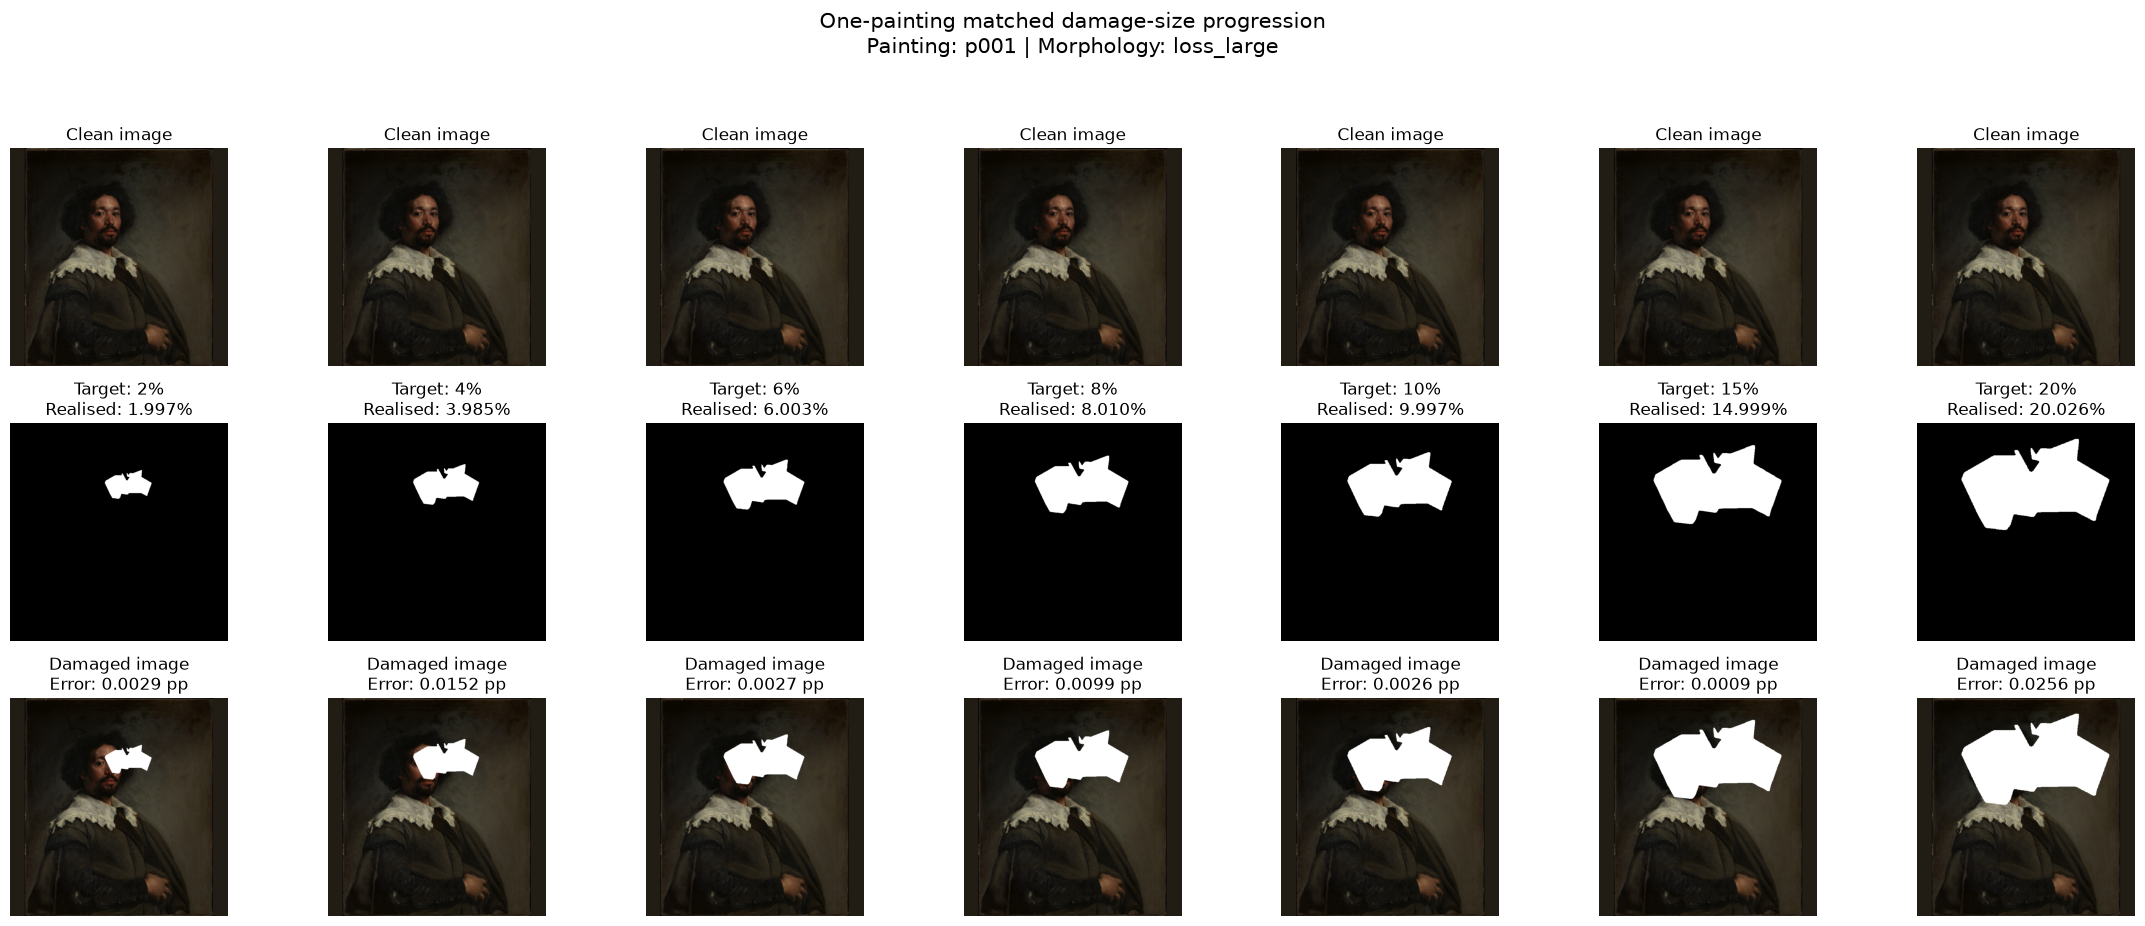

One-painting progression figure saved:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\damage_size_sensitivity\one_painting_damage_size_progression.png


In [8]:
# Visualise the one-painting, seven-level matched size progression

clean_test_row = (
    test_processed_metadata_df.iloc[0]
)


clean_test_path = Path(
    str(
        clean_test_row[
            "processed_path"
        ]
    )
)


if not clean_test_path.is_absolute():
    clean_test_path = (
        PROJECT_ROOT
        / clean_test_path
    )


if not clean_test_path.exists():
    raise FileNotFoundError(
        "Clean test image not found: "
        f"{clean_test_path}"
    )


with Image.open(
    clean_test_path
) as opened_clean_test_image:
    clean_test_array = np.asarray(
        opened_clean_test_image.convert(
            "RGB"
        )
    )


base_mask_type = (
    base_mask_types[0]
)


progression_rows_df = (
    test_sensitivity_metadata_df.loc[
        test_sensitivity_metadata_df[
            "base_mask_type"
        ]
        .astype(str)
        == base_mask_type
    ]
    .sort_values(
        "target_percentage_content",
        kind="stable",
    )
    .reset_index(drop=True)
)


if (
    len(progression_rows_df)
    != expected_test_case_count
):
    raise RuntimeError(
        "Progression visualisation requires "
        f"{expected_test_case_count} cases: "
        f"observed={len(progression_rows_df)}"
    )


observed_progression_targets = tuple(
    progression_rows_df[
        "target_percentage_content"
    ]
    .astype(float)
    .tolist()
)


if (
    observed_progression_targets
    != target_percentages
):
    raise RuntimeError(
        "Progression rows do not match the "
        "configured target order: "
        f"observed={observed_progression_targets}, "
        f"expected={target_percentages}"
    )


test_progression_figure_path = (
    sensitivity_figure_dir
    / "one_painting_damage_size_progression.png"
)


figure, axes = plt.subplots(
    3,
    expected_test_case_count,
    figsize=(
        3.2 * expected_test_case_count,
        9.4,
    ),
    squeeze=False,
)


for column_index, case_row in (
    progression_rows_df.iterrows()
):
    sensitivity_mask_path = Path(
        str(
            case_row[
                "sensitivity_mask_path"
            ]
        )
    )

    damaged_path = Path(
        str(
            case_row[
                "damaged_path"
            ]
        )
    )


    if not sensitivity_mask_path.is_absolute():
        sensitivity_mask_path = (
            PROJECT_ROOT
            / sensitivity_mask_path
        )

    if not damaged_path.is_absolute():
        damaged_path = (
            PROJECT_ROOT
            / damaged_path
        )


    if not sensitivity_mask_path.exists():
        raise FileNotFoundError(
            "Test sensitivity mask is missing: "
            f"{sensitivity_mask_path}"
        )

    if not damaged_path.exists():
        raise FileNotFoundError(
            "Test damaged image is missing: "
            f"{damaged_path}"
        )


    with Image.open(
        sensitivity_mask_path
    ) as opened_mask_image:
        sensitivity_mask_array = np.asarray(
            opened_mask_image.convert(
                "L"
            )
        )


    with Image.open(
        damaged_path
    ) as opened_damaged_image:
        damaged_array = np.asarray(
            opened_damaged_image.convert(
                "RGB"
            )
        )


    target_percentage = float(
        case_row[
            "target_percentage_content"
        ]
    )

    realised_percentage = float(
        case_row[
            "realised_percentage_content"
        ]
    )

    absolute_percentage_error = float(
        case_row[
            "absolute_percentage_error_content"
        ]
    )


    axes[
        0,
        column_index,
    ].imshow(
        clean_test_array
    )

    axes[
        0,
        column_index,
    ].set_title(
        "Clean image"
    )

    axes[
        0,
        column_index,
    ].axis(
        "off"
    )


    axes[
        1,
        column_index,
    ].imshow(
        sensitivity_mask_array,
        cmap="gray",
        vmin=0,
        vmax=255,
    )

    axes[
        1,
        column_index,
    ].set_title(
        (
            f"Target: {target_percentage:.0f}%\n"
            f"Realised: {realised_percentage:.3f}%"
        )
    )

    axes[
        1,
        column_index,
    ].axis(
        "off"
    )


    axes[
        2,
        column_index,
    ].imshow(
        damaged_array
    )

    axes[
        2,
        column_index,
    ].set_title(
        (
            f"Damaged image\n"
            f"Error: {absolute_percentage_error:.4f} pp"
        )
    )

    axes[
        2,
        column_index,
    ].axis(
        "off"
    )


figure.suptitle(
    (
        "One-painting matched damage-size progression\n"
        f"Painting: {test_painting_id} | "
        f"Morphology: {base_mask_type}"
    ),
    fontsize=15,
)


figure.tight_layout(
    rect=[
        0,
        0,
        1,
        0.94,
    ]
)


figure.savefig(
    test_progression_figure_path,
    dpi=220,
    bbox_inches="tight",
)


plt.show()
plt.close(
    figure
)


if not test_progression_figure_path.exists():
    raise RuntimeError(
        "One-painting progression figure "
        "was not created."
    )


if (
    test_progression_figure_path.stat().st_size
    <= 0
):
    raise RuntimeError(
        "One-painting progression figure is empty."
    )


print(
    "One-painting progression figure saved:"
)

print(
    test_progression_figure_path
)

In [9]:
# Generate the full canonical 35-case damage-size sensitivity dataset

expected_case_ids = set(
    expected_case_manifest_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)


expected_mask_filenames = {
    f"{case_id}_mask.png"
    for case_id in expected_case_ids
}


expected_damaged_filenames = {
    f"{case_id}_damaged.png"
    for case_id in expected_case_ids
}


sensitivity_mask_dir.mkdir(
    parents=True,
    exist_ok=True,
)

sensitivity_damaged_dir.mkdir(
    parents=True,
    exist_ok=True,
)


existing_mask_paths = [
    path
    for path in sensitivity_mask_dir.glob(
        "*.png"
    )
    if path.is_file()
]


existing_damaged_paths = [
    path
    for path in sensitivity_damaged_dir.glob(
        "*.png"
    )
    if path.is_file()
]


stale_mask_paths = [
    path
    for path in existing_mask_paths
    if path.name
    not in expected_mask_filenames
]


stale_damaged_paths = [
    path
    for path in existing_damaged_paths
    if path.name
    not in expected_damaged_filenames
]


stale_sensitivity_file_records = []


for stale_path in stale_mask_paths:
    stale_sensitivity_file_records.append(
        {
            "file_type": (
                "sensitivity_mask"
            ),
            "filename": stale_path.name,
            "path": str(
                stale_path
            ),
        }
    )


for stale_path in stale_damaged_paths:
    stale_sensitivity_file_records.append(
        {
            "file_type": (
                "damaged_image"
            ),
            "filename": stale_path.name,
            "path": str(
                stale_path
            ),
        }
    )


stale_sensitivity_files_df = pd.DataFrame(
    stale_sensitivity_file_records
)


if not stale_sensitivity_files_df.empty:
    print(
        "Removing stale sensitivity artifacts"
    )

    display(
        stale_sensitivity_files_df
    )


for stale_path in [
    *stale_mask_paths,
    *stale_damaged_paths,
]:
    stale_path.unlink()


remaining_stale_mask_paths = [
    path
    for path in stale_mask_paths
    if path.exists()
]


remaining_stale_damaged_paths = [
    path
    for path in stale_damaged_paths
    if path.exists()
]


if (
    remaining_stale_mask_paths
    or remaining_stale_damaged_paths
):
    raise RuntimeError(
        "One or more stale sensitivity artifacts "
        "could not be removed."
    )


full_generation_started_at_utc = (
    datetime.now(
        timezone.utc
    ).isoformat()
)


sensitivity_metadata_df = (
    create_damage_size_sensitivity_dataset(
        processed_metadata=(
            sensitivity_processed_metadata_df
        ),
        mask_metadata=(
            selected_base_mask_metadata_df
        ),
        target_percentages=(
            target_percentages
        ),
        output_mask_dir=(
            sensitivity_mask_dir
        ),
        output_damaged_dir=(
            sensitivity_damaged_dir
        ),
        project_root=PROJECT_ROOT,
        base_mask_types=(
            base_mask_types
        ),
        fill_color=(
            damage_fill_color
        ),
        fill_strategy=(
            damage_fill_strategy
        ),
        global_seed=global_seed,
        overwrite=True,
        compute_checksums=True,
    )
)


full_generation_completed_at_utc = (
    datetime.now(
        timezone.utc
    ).isoformat()
)


print(
    "Full generation started:",
    full_generation_started_at_utc,
)

print(
    "Full generation completed:",
    full_generation_completed_at_utc,
)

print(
    "Generated rows:",
    len(sensitivity_metadata_df),
)


if sensitivity_metadata_df.empty:
    raise RuntimeError(
        "Full sensitivity generation returned "
        "no metadata rows."
    )


required_generation_columns = [
    "case_id",
    "painting_id",
    "base_mask_type",
    "target_percentage_content",
    "realised_percentage_content",
    "absolute_percentage_error_content",
    "deterministic_seed",
    "global_seed",
    "sensitivity_mask_path",
    "damaged_path",
    "sensitivity_mask_sha256",
    "damaged_sha256",
    "generator_name",
    "generator_version",
    "generated_at_utc",
    "status",
]


missing_generation_columns = [
    column_name
    for column_name in required_generation_columns
    if column_name
    not in sensitivity_metadata_df.columns
]


if missing_generation_columns:
    raise RuntimeError(
        "Sensitivity metadata is missing required "
        "generation columns: "
        f"{missing_generation_columns}"
    )


sensitivity_metadata_df[
    "painting_id"
] = (
    sensitivity_metadata_df[
        "painting_id"
    ]
    .astype(str)
)


sensitivity_metadata_df[
    "case_id"
] = (
    sensitivity_metadata_df[
        "case_id"
    ]
    .astype(str)
)


if (
    len(sensitivity_metadata_df)
    != expected_case_count
):
    raise RuntimeError(
        "Full sensitivity generation produced an "
        "invalid number of rows: "
        f"observed={len(sensitivity_metadata_df)}, "
        f"expected={expected_case_count}"
    )


duplicate_generated_case_rows_df = (
    sensitivity_metadata_df.loc[
        sensitivity_metadata_df[
            "case_id"
        ]
        .duplicated(
            keep=False
        )
    ]
    .copy()
)


if not duplicate_generated_case_rows_df.empty:
    display(
        duplicate_generated_case_rows_df
    )

    raise RuntimeError(
        "Full sensitivity generation contains "
        "duplicate case IDs."
    )


generated_case_ids = set(
    sensitivity_metadata_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)


missing_generated_case_ids = sorted(
    expected_case_ids
    - generated_case_ids
)


unexpected_generated_case_ids = sorted(
    generated_case_ids
    - expected_case_ids
)


if (
    missing_generated_case_ids
    or unexpected_generated_case_ids
):
    print(
        "Missing generated case IDs:",
        missing_generated_case_ids,
    )

    print(
        "Unexpected generated case IDs:",
        unexpected_generated_case_ids,
    )

    raise RuntimeError(
        "Generated sensitivity case inventory "
        "does not match the expected manifest."
    )


generation_failure_rows_df = (
    sensitivity_metadata_df.loc[
        sensitivity_metadata_df[
            "status"
        ]
        .astype(str)
        != "ok"
    ]
    .copy()
)


if not generation_failure_rows_df.empty:
    display(
        generation_failure_rows_df
    )

    raise RuntimeError(
        "Full sensitivity generation produced "
        "unsuccessful rows."
    )


observed_generation_targets = tuple(
    sorted(
        sensitivity_metadata_df[
            "target_percentage_content"
        ]
        .astype(float)
        .unique()
        .tolist()
    )
)


if (
    observed_generation_targets
    != target_percentages
):
    raise RuntimeError(
        "Generated target inventory does not match "
        "the configured levels: "
        f"observed={observed_generation_targets}, "
        f"expected={target_percentages}"
    )


generated_distribution_df = (
    sensitivity_metadata_df
    .groupby(
        [
            "base_mask_type",
            "target_percentage_content",
        ],
        sort=True,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
    )
    .reset_index()
)


invalid_generated_distribution_df = (
    generated_distribution_df.loc[
        (
            generated_distribution_df[
                "case_count"
            ]
            != expected_painting_count
        )
        |
        (
            generated_distribution_df[
                "painting_count"
            ]
            != expected_painting_count
        )
    ]
    .copy()
)


if not invalid_generated_distribution_df.empty:
    display(
        invalid_generated_distribution_df
    )

    raise RuntimeError(
        "Generated sensitivity target "
        "distribution is invalid."
    )


if not (
    sensitivity_metadata_df[
        "global_seed"
    ]
    .astype(int)
    .eq(global_seed)
    .all()
):
    raise RuntimeError(
        "Generated metadata contains an "
        "unexpected global seed."
    )


generator_names = sorted(
    sensitivity_metadata_df[
        "generator_name"
    ]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)


generator_versions = sorted(
    sensitivity_metadata_df[
        "generator_version"
    ]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)


if generator_names != [
    GENERATOR_NAME
]:
    raise RuntimeError(
        "Generated metadata contains an "
        "unexpected generator name: "
        f"{generator_names}"
    )


if generator_versions != [
    GENERATOR_VERSION
]:
    raise RuntimeError(
        "Generated metadata contains an "
        "unexpected generator version: "
        f"{generator_versions}"
    )


generated_display_columns = [
    column_name
    for column_name in [
        "case_id",
        "painting_id",
        "base_mask_type",
        "target_percentage_content",
        "realised_percentage_content",
        "absolute_percentage_error_content",
        "absolute_pixel_error",
        "scale_factor",
        "deterministic_seed",
        "generation_action",
        "status",
    ]
    if column_name
    in sensitivity_metadata_df.columns
]


display(
    sensitivity_metadata_df[
        generated_display_columns
    ]
    .sort_values(
        [
            "painting_id",
            "target_percentage_content",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


display(
    generated_distribution_df
)


print(
    "\nFull canonical 35-case sensitivity "
    "generation passed."
)

Full generation started: 2026-07-24T20:32:19.955682+00:00
Full generation completed: 2026-07-24T20:32:36.343652+00:00
Generated rows: 35


,case_id,painting_id,base_mask_type,target_percentage_content,realised_percentage_content,absolute_percentage_error_content,absolute_pixel_error,scale_factor,deterministic_seed,generation_action,status
0,p001__loss_large__size_02pct,p001,loss_large,2.0,1.997117,0.002883,15,0.384048,1367668169,generated,ok
1,p001__loss_large__size_04pct,p001,loss_large,4.0,3.984807,0.015193,77,0.542068,1367668169,generated,ok
2,p001__loss_large__size_06pct,p001,loss_large,6.0,6.002742,0.002742,14,0.665179,1367668169,generated,ok
3,p001__loss_large__size_08pct,p001,loss_large,8.0,8.009875,0.009875,50,0.769563,1367668169,generated,ok
4,p001__loss_large__size_10pct,p001,loss_large,10.0,9.997368,0.002632,13,0.858740,1367668169,generated,ok
5,p001__loss_large__size_15pct,p001,loss_large,15.0,14.999097,0.000903,5,1.051744,1367668169,generated,ok
6,p001__loss_large__size_20pct,p001,loss_large,20.0,20.025570,0.025570,130,1.214448,1367668169,generated,ok
7,p018__loss_large__size_02pct,p018,loss_large,2.0,1.997298,0.002702,11,0.429353,115339684,generated,ok
8,p018__loss_large__size_04pct,p018,loss_large,4.0,3.988690,0.011310,44,0.605609,115339684,generated,ok
9,p018__loss_large__size_06pct,p018,loss_large,6.0,6.011413,0.011413,44,0.741724,115339684,generated,ok


,base_mask_type,target_percentage_content,case_count,painting_count
0,loss_large,2.0,5,5
1,loss_large,4.0,5,5
2,loss_large,6.0,5,5
3,loss_large,8.0,5,5
4,loss_large,10.0,5,5
5,loss_large,15.0,5,5
6,loss_large,20.0,5,5



Full canonical 35-case sensitivity generation passed.


In [10]:
# Validate the full canonical damage-size sensitivity dataset

sensitivity_validation_df = (
    validate_damage_size_sensitivity_dataset(
        sensitivity_metadata=(
            sensitivity_metadata_df
        ),
        project_root=PROJECT_ROOT,
        verify_checksums=True,
        maximum_percentage_error=(
            maximum_percentage_error
        ),
    )
)


if sensitivity_validation_df.empty:
    raise RuntimeError(
        "Sensitivity validation returned "
        "an empty result."
    )


if (
    len(sensitivity_validation_df)
    != expected_case_count
):
    raise RuntimeError(
        "Sensitivity validation row count "
        "is invalid: "
        f"observed={len(sensitivity_validation_df)}, "
        f"expected={expected_case_count}"
    )


required_validation_columns = [
    "case_id",
    "target_error_valid",
    "outside_mask_changed_pixels",
    "outside_mask_preserved",
    "inside_mask_not_fill_pixels",
    "masked_fill_valid",
    "checksum_valid",
    "validation_passed",
]


missing_validation_columns = [
    column_name
    for column_name in required_validation_columns
    if column_name
    not in sensitivity_validation_df.columns
]


if missing_validation_columns:
    raise RuntimeError(
        "Sensitivity validation is missing required "
        "columns: "
        f"{missing_validation_columns}"
    )


sensitivity_validation_df[
    "case_id"
] = (
    sensitivity_validation_df[
        "case_id"
    ]
    .astype(str)
)


duplicate_validation_case_rows_df = (
    sensitivity_validation_df.loc[
        sensitivity_validation_df[
            "case_id"
        ]
        .duplicated(
            keep=False
        )
    ]
    .copy()
)


if not duplicate_validation_case_rows_df.empty:
    display(
        duplicate_validation_case_rows_df
    )

    raise RuntimeError(
        "Sensitivity validation contains "
        "duplicate case IDs."
    )


metadata_case_ids = set(
    sensitivity_metadata_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)


validation_case_ids = set(
    sensitivity_validation_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)


missing_validation_case_ids = sorted(
    metadata_case_ids
    - validation_case_ids
)


unexpected_validation_case_ids = sorted(
    validation_case_ids
    - metadata_case_ids
)


if (
    missing_validation_case_ids
    or unexpected_validation_case_ids
):
    print(
        "Missing validation case IDs:",
        missing_validation_case_ids,
    )

    print(
        "Unexpected validation case IDs:",
        unexpected_validation_case_ids,
    )

    raise RuntimeError(
        "Validation case inventory does not match "
        "the generated metadata."
    )


validation_failure_rows_df = (
    sensitivity_validation_df.loc[
        ~sensitivity_validation_df[
            "validation_passed"
        ]
        .astype(bool)
    ]
    .copy()
)


target_error_failure_rows_df = (
    sensitivity_validation_df.loc[
        ~sensitivity_validation_df[
            "target_error_valid"
        ]
        .astype(bool)
    ]
    .copy()
)


outside_mask_failure_rows_df = (
    sensitivity_validation_df.loc[
        ~sensitivity_validation_df[
            "outside_mask_preserved"
        ]
        .astype(bool)
    ]
    .copy()
)


masked_fill_failure_rows_df = (
    sensitivity_validation_df.loc[
        ~sensitivity_validation_df[
            "masked_fill_valid"
        ]
        .astype(bool)
    ]
    .copy()
)


checksum_failure_rows_df = (
    sensitivity_validation_df.loc[
        ~sensitivity_validation_df[
            "checksum_valid"
        ]
        .astype(bool)
    ]
    .copy()
)


full_validation_summary_df = pd.DataFrame(
    [
        {
            "check": "validation_rows",
            "observed": len(
                sensitivity_validation_df
            ),
            "expected": expected_case_count,
            "passed": (
                len(
                    sensitivity_validation_df
                )
                == expected_case_count
            ),
        },
        {
            "check": "unique_validation_cases",
            "observed": (
                sensitivity_validation_df[
                    "case_id"
                ]
                .nunique()
            ),
            "expected": expected_case_count,
            "passed": (
                sensitivity_validation_df[
                    "case_id"
                ]
                .nunique()
                == expected_case_count
            ),
        },
        {
            "check": "validation_failures",
            "observed": len(
                validation_failure_rows_df
            ),
            "expected": 0,
            "passed": (
                validation_failure_rows_df.empty
            ),
        },
        {
            "check": "target_error_failures",
            "observed": len(
                target_error_failure_rows_df
            ),
            "expected": 0,
            "passed": (
                target_error_failure_rows_df.empty
            ),
        },
        {
            "check": "outside_mask_changes",
            "observed": int(
                pd.to_numeric(
                    sensitivity_validation_df[
                        "outside_mask_changed_pixels"
                    ],
                    errors="coerce",
                )
                .fillna(0)
                .sum()
            ),
            "expected": 0,
            "passed": (
                outside_mask_failure_rows_df.empty
            ),
        },
        {
            "check": "inside_mask_fill_failures",
            "observed": int(
                pd.to_numeric(
                    sensitivity_validation_df[
                        "inside_mask_not_fill_pixels"
                    ],
                    errors="coerce",
                )
                .fillna(0)
                .sum()
            ),
            "expected": 0,
            "passed": (
                masked_fill_failure_rows_df.empty
            ),
        },
        {
            "check": "checksum_failures",
            "observed": len(
                checksum_failure_rows_df
            ),
            "expected": 0,
            "passed": (
                checksum_failure_rows_df.empty
            ),
        },
    ]
)


print("Full sensitivity validation summary")
print("-----------------------------------")

display(
    full_validation_summary_df
)


if not validation_failure_rows_df.empty:
    print("\nFailed validation rows")

    display(
        validation_failure_rows_df
    )


failed_full_validation_summary_df = (
    full_validation_summary_df.loc[
        ~full_validation_summary_df[
            "passed"
        ]
        .astype(bool)
    ]
    .copy()
)


if not failed_full_validation_summary_df.empty:
    display(
        failed_full_validation_summary_df
    )

    raise RuntimeError(
        "Full damage-size sensitivity "
        "validation failed."
    )


validation_display_columns = [
    column_name
    for column_name in [
        "case_id",
        "target_error_valid",
        "outside_mask_changed_pixels",
        "outside_mask_preserved",
        "inside_mask_not_fill_pixels",
        "masked_fill_valid",
        "checksum_valid",
        "validation_passed",
    ]
    if column_name
    in sensitivity_validation_df.columns
]


display(
    sensitivity_validation_df[
        validation_display_columns
    ]
    .sort_values(
        "case_id",
        kind="stable",
    )
    .reset_index(drop=True)
)


print(
    "\nAll 35 sensitivity cases passed "
    "canonical validation."
)

Full sensitivity validation summary
-----------------------------------


,check,observed,expected,passed
0,validation_rows,35,35,True
1,unique_validation_cases,35,35,True
2,validation_failures,0,0,True
3,target_error_failures,0,0,True
4,outside_mask_changes,0,0,True
5,inside_mask_fill_failures,0,0,True
6,checksum_failures,0,0,True


,case_id,target_error_valid,outside_mask_changed_pixels,outside_mask_preserved,inside_mask_not_fill_pixels,masked_fill_valid,checksum_valid,validation_passed
0,p001__loss_large__size_02pct,True,0,True,0,True,True,True
1,p001__loss_large__size_04pct,True,0,True,0,True,True,True
2,p001__loss_large__size_06pct,True,0,True,0,True,True,True
3,p001__loss_large__size_08pct,True,0,True,0,True,True,True
4,p001__loss_large__size_10pct,True,0,True,0,True,True,True
5,p001__loss_large__size_15pct,True,0,True,0,True,True,True
6,p001__loss_large__size_20pct,True,0,True,0,True,True,True
7,p018__loss_large__size_02pct,True,0,True,0,True,True,True
8,p018__loss_large__size_04pct,True,0,True,0,True,True,True
9,p018__loss_large__size_06pct,True,0,True,0,True,True,True



All 35 sensitivity cases passed canonical validation.


In [11]:
# Finalize, save, and reload the canonical sensitivity metadata

sensitivity_metadata_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)


sensitivity_metadata_to_save_df = (
    sensitivity_metadata_df
    .copy()
)


sensitivity_metadata_to_save_df[
    "config_version"
] = config_version

sensitivity_metadata_to_save_df[
    "experiment_name"
] = experiment_name

sensitivity_metadata_to_save_df[
    "experiment_version"
] = experiment_version

sensitivity_metadata_to_save_df[
    "notebook_stage"
] = "05_damage_size_sensitivity"

sensitivity_metadata_to_save_df[
    "full_generation_started_at_utc"
] = full_generation_started_at_utc

sensitivity_metadata_to_save_df[
    "full_generation_completed_at_utc"
] = full_generation_completed_at_utc


sensitivity_metadata_to_save_df = (
    sensitivity_metadata_to_save_df
    .sort_values(
        [
            "painting_id",
            "base_mask_type",
            "target_percentage_content",
            "case_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


required_canonical_metadata_columns = [
    "case_id",
    "painting_id",
    "base_mask_type",
    "target_percentage_content",
    "realised_percentage_content",
    "absolute_percentage_error_content",
    "deterministic_seed",
    "global_seed",
    "sensitivity_mask_path",
    "damaged_path",
    "sensitivity_mask_sha256",
    "damaged_sha256",
    "generator_name",
    "generator_version",
    "generated_at_utc",
    "status",
    "config_version",
    "experiment_name",
    "experiment_version",
    "notebook_stage",
]


missing_canonical_metadata_columns = [
    column_name
    for column_name
    in required_canonical_metadata_columns
    if column_name
    not in sensitivity_metadata_to_save_df.columns
]


if missing_canonical_metadata_columns:
    raise RuntimeError(
        "Canonical sensitivity metadata is missing "
        "required columns: "
        f"{missing_canonical_metadata_columns}"
    )


if (
    len(sensitivity_metadata_to_save_df)
    != expected_case_count
):
    raise RuntimeError(
        "Canonical sensitivity metadata row count "
        "is invalid: "
        f"observed={len(sensitivity_metadata_to_save_df)}, "
        f"expected={expected_case_count}"
    )


duplicate_canonical_case_rows_df = (
    sensitivity_metadata_to_save_df.loc[
        sensitivity_metadata_to_save_df[
            "case_id"
        ]
        .astype(str)
        .duplicated(
            keep=False
        )
    ]
    .copy()
)


if not duplicate_canonical_case_rows_df.empty:
    display(
        duplicate_canonical_case_rows_df
    )

    raise RuntimeError(
        "Canonical sensitivity metadata contains "
        "duplicate case IDs."
    )


required_value_audit_df = (
    sensitivity_metadata_to_save_df[
        required_canonical_metadata_columns
    ]
    .isna()
    .sum()
    .rename(
        "missing_count"
    )
    .reset_index()
    .rename(
        columns={
            "index": "column",
        }
    )
)


display(
    required_value_audit_df
)


if (
    required_value_audit_df[
        "missing_count"
    ]
    > 0
).any():
    raise RuntimeError(
        "Canonical sensitivity metadata contains "
        "missing required values."
    )


if not (
    sensitivity_metadata_to_save_df[
        "status"
    ]
    .astype(str)
    .eq("ok")
    .all()
):
    invalid_status_rows_df = (
        sensitivity_metadata_to_save_df.loc[
            sensitivity_metadata_to_save_df[
                "status"
            ]
            .astype(str)
            .ne("ok")
        ]
        .copy()
    )

    display(
        invalid_status_rows_df
    )

    raise RuntimeError(
        "Canonical sensitivity metadata contains "
        "unsuccessful generation rows."
    )


temporary_sensitivity_metadata_path = (
    sensitivity_metadata_path.with_suffix(
        ".tmp.csv"
    )
)


sensitivity_metadata_to_save_df.to_csv(
    temporary_sensitivity_metadata_path,
    index=False,
)


temporary_sensitivity_metadata_path.replace(
    sensitivity_metadata_path
)


if not sensitivity_metadata_path.exists():
    raise RuntimeError(
        "Canonical sensitivity metadata was not saved."
    )


if sensitivity_metadata_path.stat().st_size <= 0:
    raise RuntimeError(
        "Canonical sensitivity metadata file is empty."
    )


reloaded_sensitivity_metadata_df = pd.read_csv(
    sensitivity_metadata_path
)


if (
    len(reloaded_sensitivity_metadata_df)
    != len(sensitivity_metadata_to_save_df)
):
    raise RuntimeError(
        "Reloaded sensitivity metadata row count "
        "does not match the saved dataframe."
    )


if list(
    reloaded_sensitivity_metadata_df.columns
) != list(
    sensitivity_metadata_to_save_df.columns
):
    raise RuntimeError(
        "Reloaded sensitivity metadata columns "
        "do not match the saved dataframe."
    )


string_comparison_columns = [
    column_name
    for column_name in [
        "case_id",
        "painting_id",
        "base_mask_type",
        "sensitivity_mask_path",
        "damaged_path",
        "sensitivity_mask_sha256",
        "damaged_sha256",
        "generator_name",
        "generator_version",
        "status",
        "config_version",
        "experiment_name",
        "experiment_version",
        "notebook_stage",
    ]
    if column_name
    in sensitivity_metadata_to_save_df.columns
]


for column_name in string_comparison_columns:
    original_values = (
        sensitivity_metadata_to_save_df[
            column_name
        ]
        .fillna("")
        .astype(str)
        .tolist()
    )

    reloaded_values = (
        reloaded_sensitivity_metadata_df[
            column_name
        ]
        .fillna("")
        .astype(str)
        .tolist()
    )

    if original_values != reloaded_values:
        raise RuntimeError(
            "Reload verification failed for "
            f"string column: {column_name}"
        )


numeric_comparison_columns = [
    column_name
    for column_name in [
        "target_percentage_content",
        "realised_percentage_content",
        "absolute_percentage_error_content",
        "absolute_pixel_error",
        "scale_factor",
        "deterministic_seed",
        "global_seed",
    ]
    if column_name
    in sensitivity_metadata_to_save_df.columns
]


for column_name in numeric_comparison_columns:
    original_values = pd.to_numeric(
        sensitivity_metadata_to_save_df[
            column_name
        ],
        errors="coerce",
    ).to_numpy()

    reloaded_values = pd.to_numeric(
        reloaded_sensitivity_metadata_df[
            column_name
        ],
        errors="coerce",
    ).to_numpy()

    if not np.allclose(
        original_values,
        reloaded_values,
        equal_nan=True,
    ):
        raise RuntimeError(
            "Reload verification failed for "
            f"numeric column: {column_name}"
        )


sensitivity_metadata_df = (
    reloaded_sensitivity_metadata_df.copy()
)


canonical_metadata_save_audit_df = pd.DataFrame(
    [
        {
            "check": "metadata_file_exists",
            "observed": int(
                sensitivity_metadata_path.exists()
            ),
            "expected": 1,
            "passed": (
                sensitivity_metadata_path.exists()
            ),
        },
        {
            "check": "metadata_file_nonempty",
            "observed": (
                sensitivity_metadata_path.stat().st_size
                if sensitivity_metadata_path.exists()
                else 0
            ),
            "expected": "> 0",
            "passed": (
                sensitivity_metadata_path.exists()
                and sensitivity_metadata_path.stat().st_size
                > 0
            ),
        },
        {
            "check": "metadata_rows",
            "observed": len(
                sensitivity_metadata_df
            ),
            "expected": expected_case_count,
            "passed": (
                len(sensitivity_metadata_df)
                == expected_case_count
            ),
        },
        {
            "check": "unique_case_ids",
            "observed": (
                sensitivity_metadata_df[
                    "case_id"
                ]
                .astype(str)
                .nunique()
            ),
            "expected": expected_case_count,
            "passed": (
                sensitivity_metadata_df[
                    "case_id"
                ]
                .astype(str)
                .nunique()
                == expected_case_count
            ),
        },
        {
            "check": "all_status_ok",
            "observed": int(
                sensitivity_metadata_df[
                    "status"
                ]
                .astype(str)
                .ne("ok")
                .sum()
            ),
            "expected": 0,
            "passed": bool(
                sensitivity_metadata_df[
                    "status"
                ]
                .astype(str)
                .eq("ok")
                .all()
            ),
        },
    ]
)


display(
    canonical_metadata_save_audit_df
)


if not canonical_metadata_save_audit_df[
    "passed"
].astype(bool).all():
    raise RuntimeError(
        "Canonical sensitivity metadata save "
        "or reload validation failed."
    )


print(
    "\nCanonical damage-size sensitivity metadata "
    "saved and reloaded successfully:"
)

print(
    sensitivity_metadata_path
)

,column,missing_count
0,case_id,0
1,painting_id,0
2,base_mask_type,0
3,target_percentage_content,0
4,realised_percentage_content,0
5,absolute_percentage_error_content,0
6,deterministic_seed,0
7,global_seed,0
8,sensitivity_mask_path,0
9,damaged_path,0


,check,observed,expected,passed
0,metadata_file_exists,1,1,True
1,metadata_file_nonempty,44298,> 0,True
2,metadata_rows,35,35,True
3,unique_case_ids,35,35,True
4,all_status_ok,0,0,True



Canonical damage-size sensitivity metadata saved and reloaded successfully:
D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_damage_size_sensitivity.csv


In [12]:
# Audit the canonical sensitivity metadata and generated-file inventory

expected_case_ids = set(
    expected_case_manifest_df[
        "case_id"
    ]
    .astype(str)
)


metadata_case_ids = set(
    sensitivity_metadata_df[
        "case_id"
    ]
    .astype(str)
)


expected_mask_filenames = {
    f"{case_id}_mask.png"
    for case_id in expected_case_ids
}


expected_damaged_filenames = {
    f"{case_id}_damaged.png"
    for case_id in expected_case_ids
}


observed_mask_file_paths = sorted(
    path
    for path in sensitivity_mask_dir.iterdir()
    if path.is_file()
)


observed_damaged_file_paths = sorted(
    path
    for path in sensitivity_damaged_dir.iterdir()
    if path.is_file()
)


observed_mask_filenames = {
    path.name
    for path in observed_mask_file_paths
    if path.suffix.lower() == ".png"
}


observed_damaged_filenames = {
    path.name
    for path in observed_damaged_file_paths
    if path.suffix.lower() == ".png"
}


missing_metadata_case_ids = sorted(
    expected_case_ids
    - metadata_case_ids
)


unexpected_metadata_case_ids = sorted(
    metadata_case_ids
    - expected_case_ids
)


missing_mask_filenames = sorted(
    expected_mask_filenames
    - observed_mask_filenames
)


orphan_mask_filenames = sorted(
    observed_mask_filenames
    - expected_mask_filenames
)


missing_damaged_filenames = sorted(
    expected_damaged_filenames
    - observed_damaged_filenames
)


orphan_damaged_filenames = sorted(
    observed_damaged_filenames
    - expected_damaged_filenames
)


non_png_mask_files = sorted(
    path.name
    for path in observed_mask_file_paths
    if path.suffix.lower() != ".png"
)


non_png_damaged_files = sorted(
    path.name
    for path in observed_damaged_file_paths
    if path.suffix.lower() != ".png"
)


zero_byte_mask_files = sorted(
    path.name
    for path in observed_mask_file_paths
    if path.stat().st_size <= 0
)


zero_byte_damaged_files = sorted(
    path.name
    for path in observed_damaged_file_paths
    if path.stat().st_size <= 0
)


duplicate_metadata_case_count = int(
    sensitivity_metadata_df[
        "case_id"
    ]
    .astype(str)
    .duplicated()
    .sum()
)


observed_painting_count = int(
    sensitivity_metadata_df[
        "painting_id"
    ]
    .astype(str)
    .nunique()
)


observed_base_mask_type_count = int(
    sensitivity_metadata_df[
        "base_mask_type"
    ]
    .astype(str)
    .nunique()
)


observed_target_level_count = int(
    pd.to_numeric(
        sensitivity_metadata_df[
            "target_percentage_content"
        ],
        errors="coerce",
    )
    .nunique()
)


invalid_status_count = int(
    sensitivity_metadata_df[
        "status"
    ]
    .astype(str)
    .ne("ok")
    .sum()
)


maximum_observed_percentage_error = float(
    pd.to_numeric(
        sensitivity_metadata_df[
            "absolute_percentage_error_content"
        ],
        errors="coerce",
    )
    .max()
)


checksum_columns = [
    "sensitivity_mask_sha256",
    "damaged_sha256",
]


missing_checksum_count = 0
invalid_checksum_length_count = 0


for checksum_column in checksum_columns:
    checksum_series = (
        sensitivity_metadata_df[
            checksum_column
        ]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    missing_checksum_count += int(
        checksum_series.eq("").sum()
    )

    non_empty_checksum_series = (
        checksum_series.loc[
            checksum_series.ne("")
        ]
    )

    invalid_checksum_length_count += int(
        non_empty_checksum_series
        .str.len()
        .ne(64)
        .sum()
    )


validation_failure_count = int(
    (
        ~sensitivity_validation_df[
            "validation_passed"
        ]
        .astype(bool)
    )
    .sum()
)


target_error_failure_count = int(
    (
        ~sensitivity_validation_df[
            "target_error_valid"
        ]
        .astype(bool)
    )
    .sum()
)


outside_mask_changed_pixel_count = int(
    pd.to_numeric(
        sensitivity_validation_df[
            "outside_mask_changed_pixels"
        ],
        errors="coerce",
    )
    .fillna(0)
    .sum()
)


inside_mask_fill_failure_pixel_count = int(
    pd.to_numeric(
        sensitivity_validation_df[
            "inside_mask_not_fill_pixels"
        ],
        errors="coerce",
    )
    .fillna(0)
    .sum()
)


damage_size_sensitivity_audit_df = pd.DataFrame(
    [
        {
            "audit_section": "metadata",
            "check": "metadata_rows",
            "observed": len(
                sensitivity_metadata_df
            ),
            "expected": expected_case_count,
            "passed": (
                len(sensitivity_metadata_df)
                == expected_case_count
            ),
            "details": "",
        },
        {
            "audit_section": "metadata",
            "check": "duplicate_case_ids",
            "observed": duplicate_metadata_case_count,
            "expected": 0,
            "passed": (
                duplicate_metadata_case_count
                == 0
            ),
            "details": "",
        },
        {
            "audit_section": "metadata",
            "check": "missing_case_ids",
            "observed": len(
                missing_metadata_case_ids
            ),
            "expected": 0,
            "passed": (
                not missing_metadata_case_ids
            ),
            "details": "; ".join(
                missing_metadata_case_ids
            ),
        },
        {
            "audit_section": "metadata",
            "check": "unexpected_case_ids",
            "observed": len(
                unexpected_metadata_case_ids
            ),
            "expected": 0,
            "passed": (
                not unexpected_metadata_case_ids
            ),
            "details": "; ".join(
                unexpected_metadata_case_ids
            ),
        },
        {
            "audit_section": "design",
            "check": "painting_count",
            "observed": observed_painting_count,
            "expected": expected_painting_count,
            "passed": (
                observed_painting_count
                == expected_painting_count
            ),
            "details": "",
        },
        {
            "audit_section": "design",
            "check": "base_mask_type_count",
            "observed": observed_base_mask_type_count,
            "expected": expected_base_mask_type_count,
            "passed": (
                observed_base_mask_type_count
                == expected_base_mask_type_count
            ),
            "details": "",
        },
        {
            "audit_section": "design",
            "check": "target_level_count",
            "observed": observed_target_level_count,
            "expected": expected_target_level_count,
            "passed": (
                observed_target_level_count
                == expected_target_level_count
            ),
            "details": "",
        },
        {
            "audit_section": "generation",
            "check": "invalid_status_rows",
            "observed": invalid_status_count,
            "expected": 0,
            "passed": (
                invalid_status_count
                == 0
            ),
            "details": "",
        },
        {
            "audit_section": "generation",
            "check": "maximum_percentage_error",
            "observed": (
                maximum_observed_percentage_error
            ),
            "expected": (
                f"<= {maximum_percentage_error}"
            ),
            "passed": (
                maximum_observed_percentage_error
                <= maximum_percentage_error
            ),
            "details": "",
        },
        {
            "audit_section": "validation",
            "check": "validation_failures",
            "observed": validation_failure_count,
            "expected": 0,
            "passed": (
                validation_failure_count
                == 0
            ),
            "details": "",
        },
        {
            "audit_section": "validation",
            "check": "target_error_failures",
            "observed": target_error_failure_count,
            "expected": 0,
            "passed": (
                target_error_failure_count
                == 0
            ),
            "details": "",
        },
        {
            "audit_section": "validation",
            "check": "outside_mask_changed_pixels",
            "observed": (
                outside_mask_changed_pixel_count
            ),
            "expected": 0,
            "passed": (
                outside_mask_changed_pixel_count
                == 0
            ),
            "details": "",
        },
        {
            "audit_section": "validation",
            "check": "inside_mask_fill_failures",
            "observed": (
                inside_mask_fill_failure_pixel_count
            ),
            "expected": 0,
            "passed": (
                inside_mask_fill_failure_pixel_count
                == 0
            ),
            "details": "",
        },
        {
            "audit_section": "checksums",
            "check": "missing_checksums",
            "observed": missing_checksum_count,
            "expected": 0,
            "passed": (
                missing_checksum_count
                == 0
            ),
            "details": "",
        },
        {
            "audit_section": "checksums",
            "check": "invalid_checksum_lengths",
            "observed": (
                invalid_checksum_length_count
            ),
            "expected": 0,
            "passed": (
                invalid_checksum_length_count
                == 0
            ),
            "details": "",
        },
        {
            "audit_section": "mask_inventory",
            "check": "mask_file_count",
            "observed": len(
                observed_mask_filenames
            ),
            "expected": expected_case_count,
            "passed": (
                len(observed_mask_filenames)
                == expected_case_count
            ),
            "details": "",
        },
        {
            "audit_section": "mask_inventory",
            "check": "missing_mask_files",
            "observed": len(
                missing_mask_filenames
            ),
            "expected": 0,
            "passed": (
                not missing_mask_filenames
            ),
            "details": "; ".join(
                missing_mask_filenames
            ),
        },
        {
            "audit_section": "mask_inventory",
            "check": "orphan_mask_files",
            "observed": len(
                orphan_mask_filenames
            ),
            "expected": 0,
            "passed": (
                not orphan_mask_filenames
            ),
            "details": "; ".join(
                orphan_mask_filenames
            ),
        },
        {
            "audit_section": "mask_inventory",
            "check": "non_png_mask_files",
            "observed": len(
                non_png_mask_files
            ),
            "expected": 0,
            "passed": (
                not non_png_mask_files
            ),
            "details": "; ".join(
                non_png_mask_files
            ),
        },
        {
            "audit_section": "mask_inventory",
            "check": "zero_byte_mask_files",
            "observed": len(
                zero_byte_mask_files
            ),
            "expected": 0,
            "passed": (
                not zero_byte_mask_files
            ),
            "details": "; ".join(
                zero_byte_mask_files
            ),
        },
        {
            "audit_section": "damaged_inventory",
            "check": "damaged_file_count",
            "observed": len(
                observed_damaged_filenames
            ),
            "expected": expected_case_count,
            "passed": (
                len(observed_damaged_filenames)
                == expected_case_count
            ),
            "details": "",
        },
        {
            "audit_section": "damaged_inventory",
            "check": "missing_damaged_files",
            "observed": len(
                missing_damaged_filenames
            ),
            "expected": 0,
            "passed": (
                not missing_damaged_filenames
            ),
            "details": "; ".join(
                missing_damaged_filenames
            ),
        },
        {
            "audit_section": "damaged_inventory",
            "check": "orphan_damaged_files",
            "observed": len(
                orphan_damaged_filenames
            ),
            "expected": 0,
            "passed": (
                not orphan_damaged_filenames
            ),
            "details": "; ".join(
                orphan_damaged_filenames
            ),
        },
        {
            "audit_section": "damaged_inventory",
            "check": "non_png_damaged_files",
            "observed": len(
                non_png_damaged_files
            ),
            "expected": 0,
            "passed": (
                not non_png_damaged_files
            ),
            "details": "; ".join(
                non_png_damaged_files
            ),
        },
        {
            "audit_section": "damaged_inventory",
            "check": "zero_byte_damaged_files",
            "observed": len(
                zero_byte_damaged_files
            ),
            "expected": 0,
            "passed": (
                not zero_byte_damaged_files
            ),
            "details": "; ".join(
                zero_byte_damaged_files
            ),
        },
    ]
)


damage_size_sensitivity_audit_df[
    "passed"
] = (
    damage_size_sensitivity_audit_df[
        "passed"
    ]
    .astype(bool)
)


damage_size_sensitivity_audit_df.to_csv(
    sensitivity_audit_path,
    index=False,
)


print("Canonical sensitivity inventory audit")
print("-------------------------------------")

display(
    damage_size_sensitivity_audit_df
)


failed_sensitivity_audit_df = (
    damage_size_sensitivity_audit_df.loc[
        ~damage_size_sensitivity_audit_df[
            "passed"
        ]
        .astype(bool)
    ]
    .copy()
)


if not failed_sensitivity_audit_df.empty:
    display(
        failed_sensitivity_audit_df
    )

    raise RuntimeError(
        "Canonical damage-size sensitivity "
        "inventory audit failed."
    )


print(
    "\nCanonical 35-case sensitivity inventory "
    "passed."
)

print(
    sensitivity_audit_path
)

Canonical sensitivity inventory audit
-------------------------------------


,audit_section,check,observed,expected,passed,details
0,metadata,metadata_rows,35.00000,35,True,
1,metadata,duplicate_case_ids,0.00000,0,True,
2,metadata,missing_case_ids,0.00000,0,True,
3,metadata,unexpected_case_ids,0.00000,0,True,
4,design,painting_count,5.00000,5,True,
5,design,base_mask_type_count,1.00000,1,True,
6,design,target_level_count,7.00000,7,True,
7,generation,invalid_status_rows,0.00000,0,True,
8,generation,maximum_percentage_error,0.02557,<= 0.5,True,
9,validation,validation_failures,0.00000,0,True,



Canonical 35-case sensitivity inventory passed.
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\05_damage_size_sensitivity\damage_size_sensitivity_audit.csv


In [13]:
# Build compact in-memory summaries for reporting and figures

summary_source_df = (
    sensitivity_metadata_df.copy()
)


required_summary_columns = [
    "case_id",
    "painting_id",
    "base_mask_type",
    "target_percentage_content",
    "realised_percentage_content",
    "absolute_percentage_error_content",
    "generator_name",
    "generator_version",
]


missing_summary_columns = [
    column_name
    for column_name in required_summary_columns
    if column_name
    not in summary_source_df.columns
]


if missing_summary_columns:
    raise RuntimeError(
        "Sensitivity metadata is missing columns "
        "required for summary generation: "
        f"{missing_summary_columns}"
    )


for column_name in [
    "target_percentage_content",
    "realised_percentage_content",
    "absolute_percentage_error_content",
]:
    summary_source_df[
        column_name
    ] = pd.to_numeric(
        summary_source_df[
            column_name
        ],
        errors="raise",
    )


generator_names = sorted(
    summary_source_df[
        "generator_name"
    ]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)


generator_versions = sorted(
    summary_source_df[
        "generator_version"
    ]
    .dropna()
    .astype(str)
    .unique()
    .tolist()
)


if generator_names != [
    GENERATOR_NAME
]:
    raise RuntimeError(
        "Unexpected generator inventory: "
        f"{generator_names}"
    )


if generator_versions != [
    GENERATOR_VERSION
]:
    raise RuntimeError(
        "Unexpected generator-version inventory: "
        f"{generator_versions}"
    )


observed_target_percentages = tuple(
    sorted(
        summary_source_df[
            "target_percentage_content"
        ]
        .unique()
        .tolist()
    )
)


if observed_target_percentages != target_percentages:
    raise RuntimeError(
        "Observed target percentages do not match "
        "the configured target levels: "
        f"observed={observed_target_percentages}, "
        f"expected={target_percentages}"
    )


overall_sensitivity_summary_df = pd.DataFrame(
    [
        {
            "painting_count": int(
                summary_source_df[
                    "painting_id"
                ].nunique()
            ),
            "base_mask_type_count": int(
                summary_source_df[
                    "base_mask_type"
                ].nunique()
            ),
            "target_level_count": int(
                summary_source_df[
                    "target_percentage_content"
                ].nunique()
            ),
            "case_count": int(
                len(summary_source_df)
            ),
            "minimum_target_percentage_content": float(
                summary_source_df[
                    "target_percentage_content"
                ].min()
            ),
            "maximum_target_percentage_content": float(
                summary_source_df[
                    "target_percentage_content"
                ].max()
            ),
            "minimum_realised_percentage_content": float(
                summary_source_df[
                    "realised_percentage_content"
                ].min()
            ),
            "maximum_realised_percentage_content": float(
                summary_source_df[
                    "realised_percentage_content"
                ].max()
            ),
            "mean_absolute_percentage_error_content": float(
                summary_source_df[
                    "absolute_percentage_error_content"
                ].mean()
            ),
            "maximum_absolute_percentage_error_content": float(
                summary_source_df[
                    "absolute_percentage_error_content"
                ].max()
            ),
            "maximum_allowed_percentage_error": float(
                maximum_percentage_error
            ),
            "global_seed": int(
                global_seed
            ),
            "fill_strategy": (
                damage_fill_strategy
            ),
            "fill_color_rgb": str(
                damage_fill_color
            ),
            "generator_name": (
                generator_names[0]
            ),
            "generator_version": (
                generator_versions[0]
            ),
        }
    ]
)


target_level_summary_df = (
    summary_source_df
    .groupby(
        [
            "base_mask_type",
            "target_percentage_content",
        ],
        sort=True,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        mean_realised_percentage_content=(
            "realised_percentage_content",
            "mean",
        ),
        standard_deviation_realised_percentage_content=(
            "realised_percentage_content",
            "std",
        ),
        minimum_realised_percentage_content=(
            "realised_percentage_content",
            "min",
        ),
        maximum_realised_percentage_content=(
            "realised_percentage_content",
            "max",
        ),
        mean_absolute_percentage_error_content=(
            "absolute_percentage_error_content",
            "mean",
        ),
        maximum_absolute_percentage_error_content=(
            "absolute_percentage_error_content",
            "max",
        ),
    )
    .reset_index()
)


painting_level_summary_df = (
    summary_source_df
    .groupby(
        "painting_id",
        sort=True,
    )
    .agg(
        case_count=(
            "case_id",
            "count",
        ),
        target_level_count=(
            "target_percentage_content",
            "nunique",
        ),
        minimum_realised_percentage_content=(
            "realised_percentage_content",
            "min",
        ),
        maximum_realised_percentage_content=(
            "realised_percentage_content",
            "max",
        ),
        mean_absolute_percentage_error_content=(
            "absolute_percentage_error_content",
            "mean",
        ),
        maximum_absolute_percentage_error_content=(
            "absolute_percentage_error_content",
            "max",
        ),
    )
    .reset_index()
)


invalid_target_level_summary_df = (
    target_level_summary_df.loc[
        (
            target_level_summary_df[
                "case_count"
            ]
            != expected_painting_count
        )
        |
        (
            target_level_summary_df[
                "painting_count"
            ]
            != expected_painting_count
        )
    ]
    .copy()
)


invalid_painting_level_summary_df = (
    painting_level_summary_df.loc[
        (
            painting_level_summary_df[
                "case_count"
            ]
            != expected_target_level_count
        )
        |
        (
            painting_level_summary_df[
                "target_level_count"
            ]
            != expected_target_level_count
        )
    ]
    .copy()
)


summary_validation_df = pd.DataFrame(
    [
        {
            "check": "overall_painting_count",
            "observed": int(
                overall_sensitivity_summary_df.loc[
                    0,
                    "painting_count",
                ]
            ),
            "expected": expected_painting_count,
            "passed": (
                overall_sensitivity_summary_df.loc[
                    0,
                    "painting_count",
                ]
                == expected_painting_count
            ),
        },
        {
            "check": "overall_mask_type_count",
            "observed": int(
                overall_sensitivity_summary_df.loc[
                    0,
                    "base_mask_type_count",
                ]
            ),
            "expected": expected_base_mask_type_count,
            "passed": (
                overall_sensitivity_summary_df.loc[
                    0,
                    "base_mask_type_count",
                ]
                == expected_base_mask_type_count
            ),
        },
        {
            "check": "overall_target_level_count",
            "observed": int(
                overall_sensitivity_summary_df.loc[
                    0,
                    "target_level_count",
                ]
            ),
            "expected": expected_target_level_count,
            "passed": (
                overall_sensitivity_summary_df.loc[
                    0,
                    "target_level_count",
                ]
                == expected_target_level_count
            ),
        },
        {
            "check": "overall_case_count",
            "observed": int(
                overall_sensitivity_summary_df.loc[
                    0,
                    "case_count",
                ]
            ),
            "expected": expected_case_count,
            "passed": (
                overall_sensitivity_summary_df.loc[
                    0,
                    "case_count",
                ]
                == expected_case_count
            ),
        },
        {
            "check": "invalid_target_level_rows",
            "observed": len(
                invalid_target_level_summary_df
            ),
            "expected": 0,
            "passed": (
                invalid_target_level_summary_df.empty
            ),
        },
        {
            "check": "invalid_painting_level_rows",
            "observed": len(
                invalid_painting_level_summary_df
            ),
            "expected": 0,
            "passed": (
                invalid_painting_level_summary_df.empty
            ),
        },
        {
            "check": "maximum_percentage_error",
            "observed": float(
                overall_sensitivity_summary_df.loc[
                    0,
                    "maximum_absolute_percentage_error_content",
                ]
            ),
            "expected": (
                f"<= {maximum_percentage_error}"
            ),
            "passed": (
                overall_sensitivity_summary_df.loc[
                    0,
                    "maximum_absolute_percentage_error_content",
                ]
                <= maximum_percentage_error
            ),
        },
    ]
)


print("Overall sensitivity summary")
print("---------------------------")

display(
    overall_sensitivity_summary_df
)


print("\nTarget-level summary")
print("--------------------")

display(
    target_level_summary_df
)


print("\nPainting-level summary")
print("----------------------")

display(
    painting_level_summary_df
)


print("\nSummary validation")
print("------------------")

display(
    summary_validation_df
)


failed_summary_validation_df = (
    summary_validation_df.loc[
        ~summary_validation_df[
            "passed"
        ]
        .astype(bool)
    ]
    .copy()
)


if not failed_summary_validation_df.empty:
    display(
        failed_summary_validation_df
    )

    raise RuntimeError(
        "Damage-size sensitivity summary "
        "validation failed."
    )


print(
    "\nCompact sensitivity summaries passed. "
    "They remain in memory for figures and reports."
)

Overall sensitivity summary
---------------------------


,painting_count,base_mask_type_count,target_level_count,case_count,minimum_target_percentage_content,maximum_target_percentage_content,minimum_realised_percentage_content,maximum_realised_percentage_content,mean_absolute_percentage_error_content,maximum_absolute_percentage_error_content,maximum_allowed_percentage_error,global_seed,fill_strategy,fill_color_rgb,generator_name,generator_version
0,5,1,7,35,2.0,20.0,1.997117,20.02557,0.008987,0.02557,0.5,20260505,constant_rgb,"(255, 255, 255)",damage_size_sensitivity,1.1.0



Target-level summary
--------------------


,base_mask_type,target_percentage_content,case_count,painting_count,mean_realised_percentage_content,standard_deviation_realised_percentage_content,minimum_realised_percentage_content,maximum_realised_percentage_content,mean_absolute_percentage_error_content,maximum_absolute_percentage_error_content
0,loss_large,2.0,5,5,2.002274,0.004710,1.997117,2.007041,0.004508,0.007041
1,loss_large,4.0,5,5,3.994237,0.007035,3.984807,4.000674,0.006033,0.015193
2,loss_large,6.0,5,5,5.999438,0.011560,5.984256,6.011413,0.009441,0.015744
3,loss_large,8.0,5,5,7.997367,0.011855,7.986342,8.009995,0.010581,0.013658
4,loss_large,10.0,5,5,10.003581,0.012025,9.990453,10.020732,0.008965,0.020732
5,loss_large,15.0,5,5,14.990585,0.010638,14.978324,15.003987,0.011010,0.021676
6,loss_large,20.0,5,5,20.007014,0.014645,19.986610,20.025570,0.012370,0.025570



Painting-level summary
----------------------


,painting_id,case_count,target_level_count,minimum_realised_percentage_content,maximum_realised_percentage_content,mean_absolute_percentage_error_content,maximum_absolute_percentage_error_content
0,p001,7,7,1.997117,20.025570,0.008543,0.025570
1,p018,7,7,1.997298,20.015615,0.011906,0.021676
2,p026,7,7,2.005307,19.986610,0.006740,0.013390
3,p039,7,7,2.004608,20.003140,0.009279,0.020732
4,p043,7,7,2.007041,20.004134,0.008466,0.015744



Summary validation
------------------


,check,observed,expected,passed
0,overall_painting_count,5.00000,5,True
1,overall_mask_type_count,1.00000,1,True
2,overall_target_level_count,7.00000,7,True
3,overall_case_count,35.00000,35,True
4,invalid_target_level_rows,0.00000,0,True
5,invalid_painting_level_rows,0.00000,0,True
6,maximum_percentage_error,0.02557,<= 0.5,True



Compact sensitivity summaries passed. They remain in memory for figures and reports.


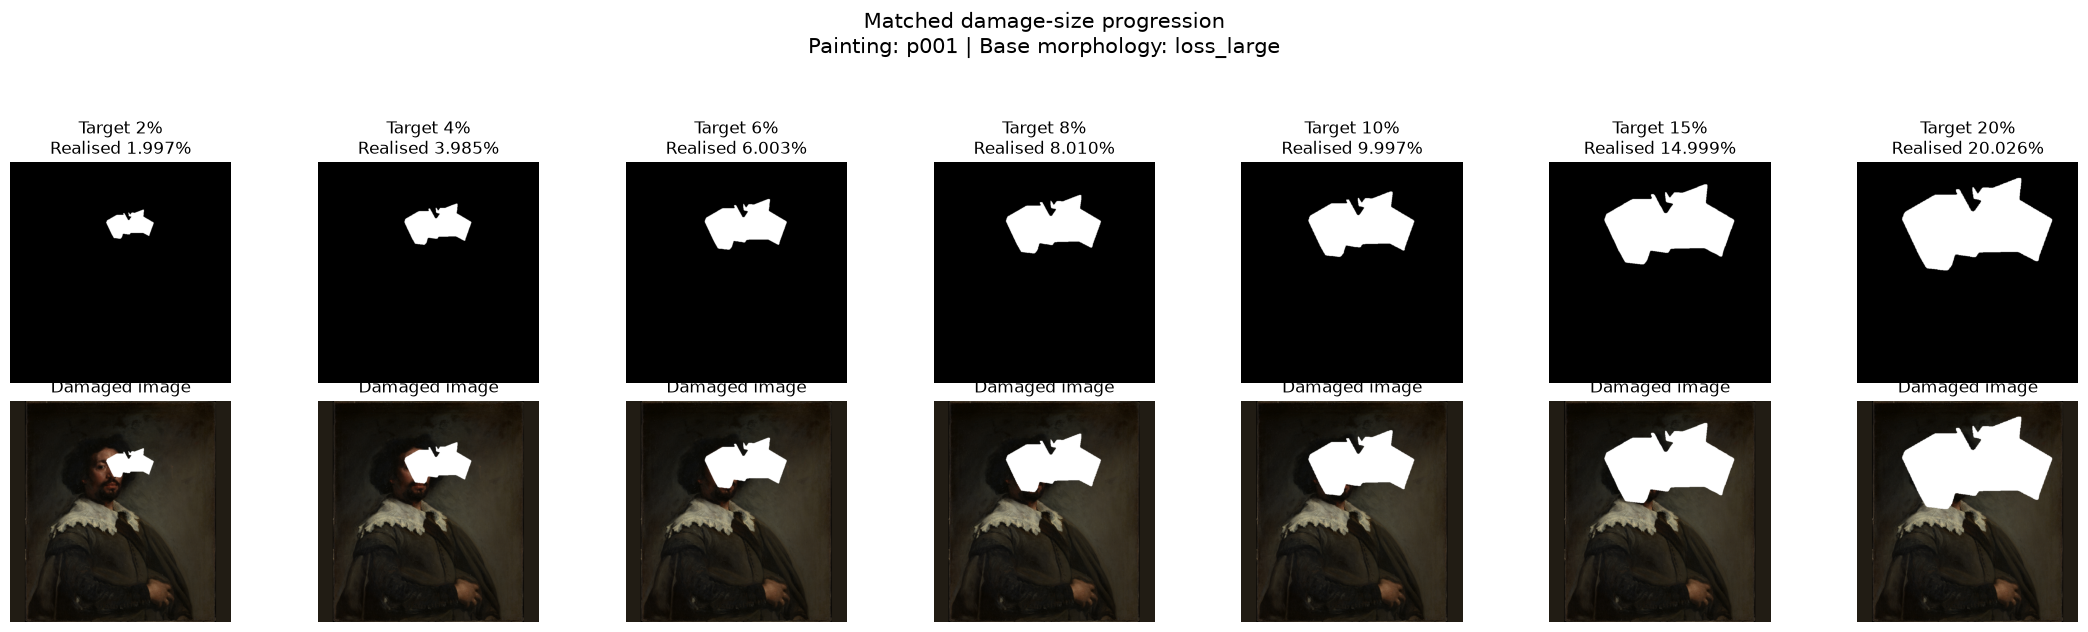

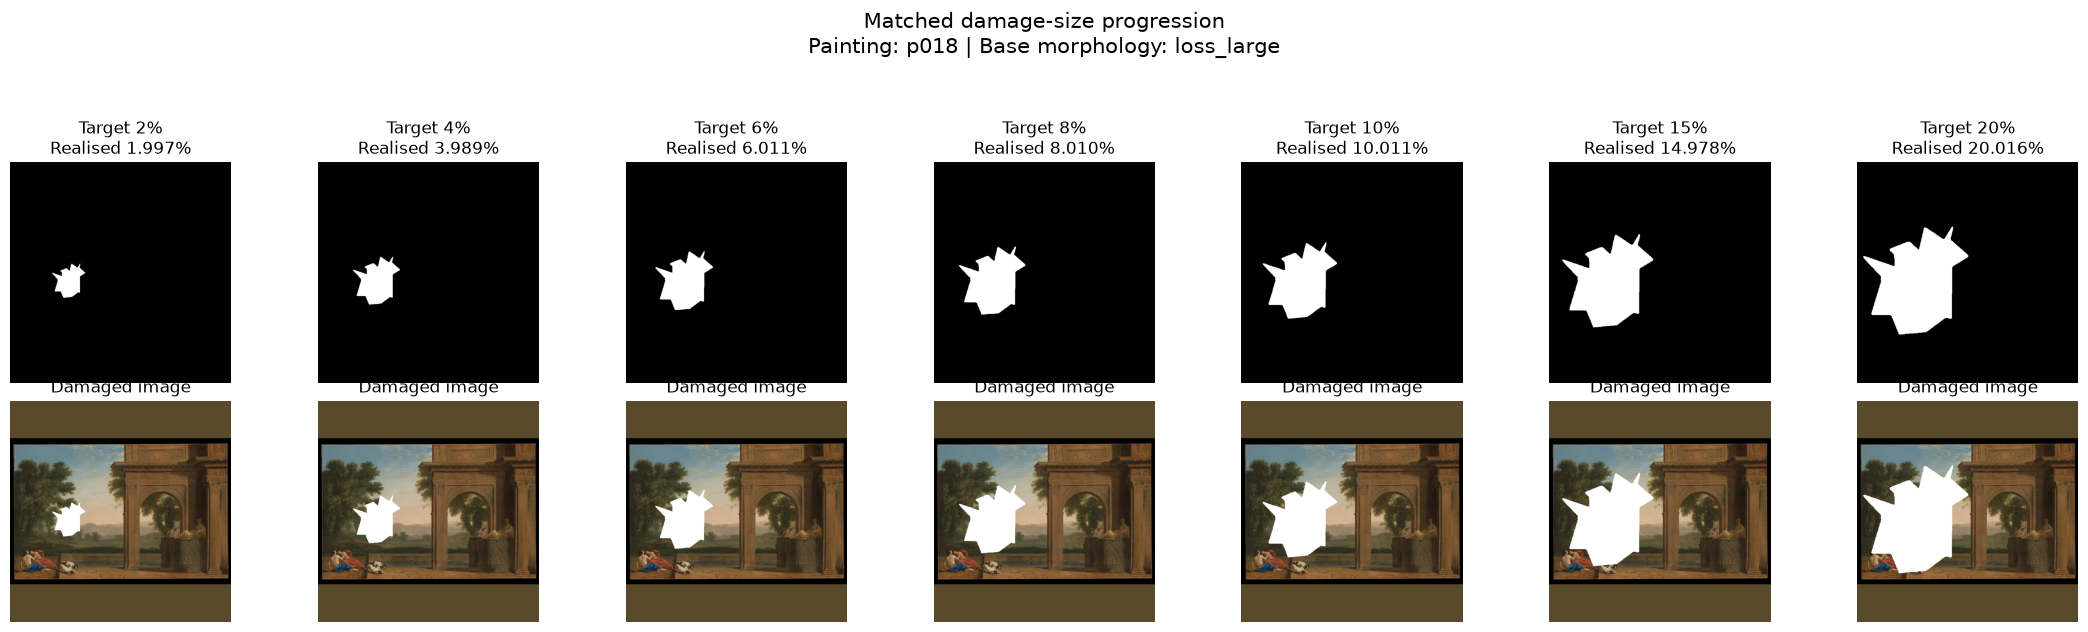

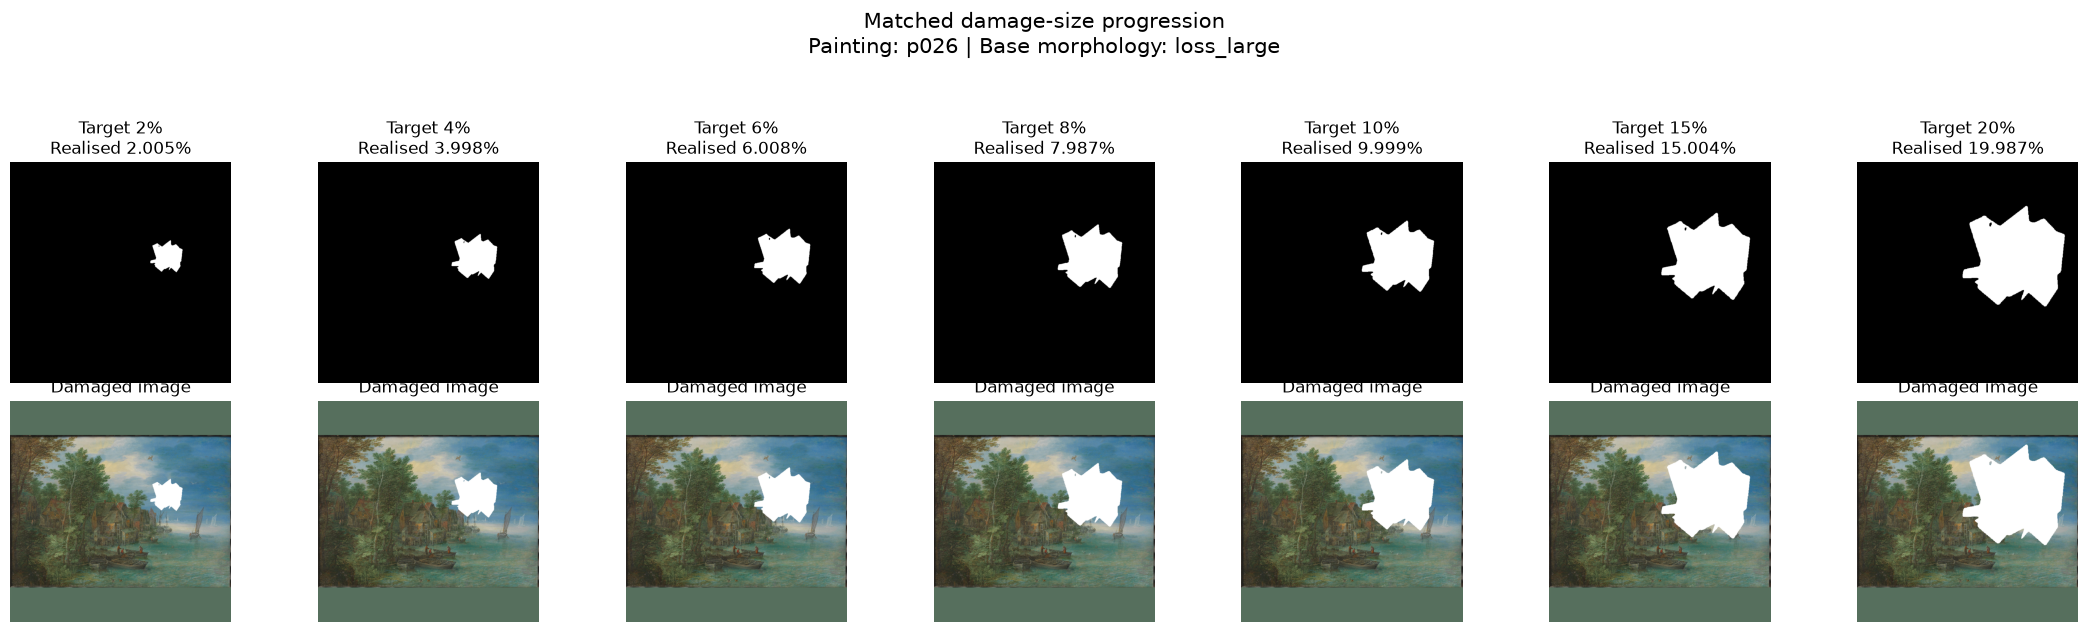

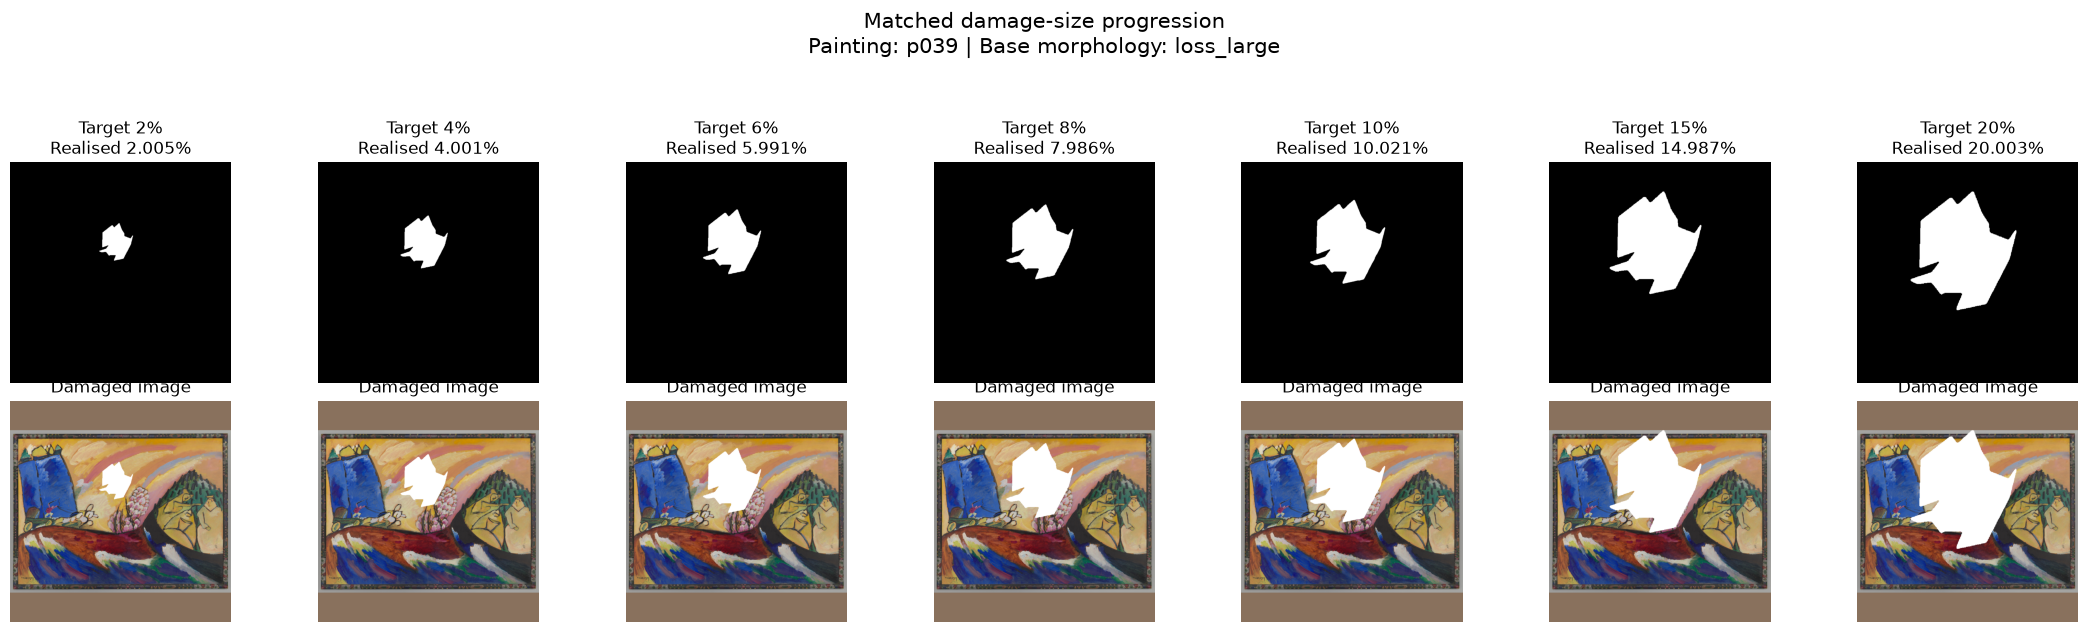

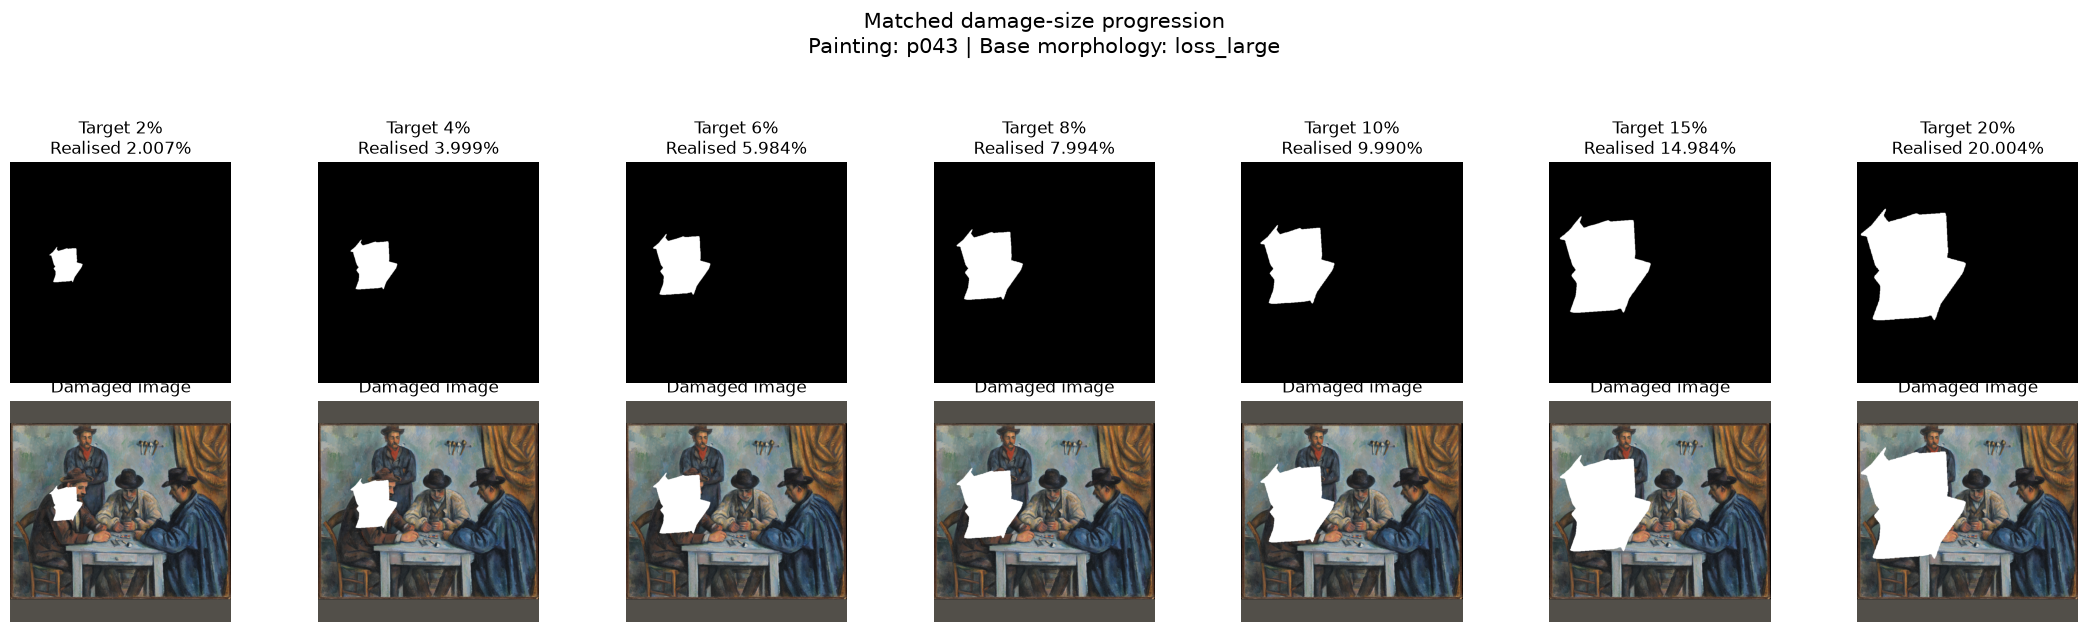

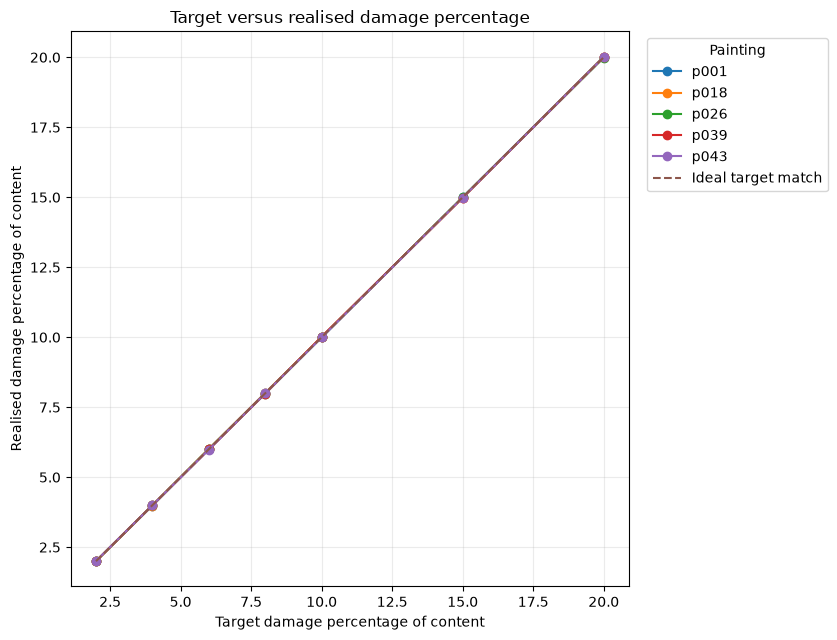

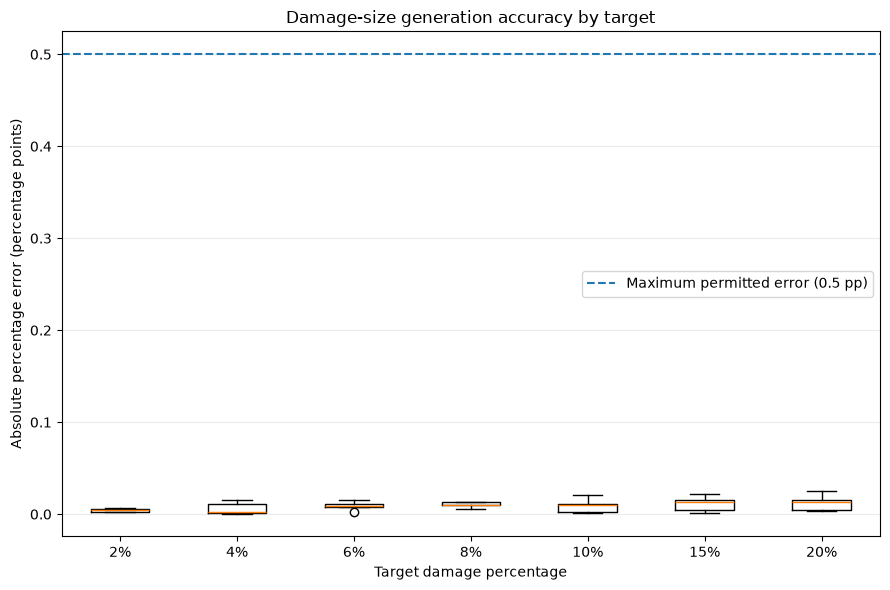

Final damage-size sensitivity figures
-------------------------------------


,figure_id,figure_type,painting_id,path
0,painting_p001_damage_size_progression,painting_progression,p001,outputs/figures/damage_size_sensitivity/painti...
1,painting_p018_damage_size_progression,painting_progression,p018,outputs/figures/damage_size_sensitivity/painti...
2,painting_p026_damage_size_progression,painting_progression,p026,outputs/figures/damage_size_sensitivity/painti...
3,painting_p039_damage_size_progression,painting_progression,p039,outputs/figures/damage_size_sensitivity/painti...
4,painting_p043_damage_size_progression,painting_progression,p043,outputs/figures/damage_size_sensitivity/painti...
5,absolute_percentage_error_by_target,target_error_distribution,,outputs/figures/damage_size_sensitivity/absolu...
6,target_vs_realised_damage_percentage,target_realised_comparison,,outputs/figures/damage_size_sensitivity/target...



Final canonical figures generated successfully.


In [14]:
# Generate final canonical damage-size sensitivity figures

def project_relative_path(
    path_value: str | Path,
) -> str:
    path = Path(path_value)

    if not path.is_absolute():
        path = PROJECT_ROOT / path

    try:
        return path.resolve().relative_to(
            PROJECT_ROOT.resolve()
        ).as_posix()
    except ValueError:
        return path.resolve().as_posix()


figure_records = []


# ---------------------------------------------------------------------
# Figure 1: one progression figure for every selected painting
# ---------------------------------------------------------------------

for painting_id in sorted(
    sensitivity_metadata_df[
        "painting_id"
    ]
    .astype(str)
    .unique()
    .tolist()
):
    painting_cases_df = (
        sensitivity_metadata_df.loc[
            sensitivity_metadata_df[
                "painting_id"
            ]
            .astype(str)
            .eq(painting_id)
        ]
        .sort_values(
            "target_percentage_content",
            kind="stable",
        )
        .reset_index(drop=True)
    )

    if (
        len(painting_cases_df)
        != expected_target_level_count
    ):
        raise RuntimeError(
            "Each painting must contain exactly "
            f"{expected_target_level_count} sensitivity cases: "
            f"painting_id={painting_id}, "
            f"observed={len(painting_cases_df)}"
        )

    clean_row_df = (
        sensitivity_processed_metadata_df.loc[
            sensitivity_processed_metadata_df[
                "painting_id"
            ]
            .astype(str)
            .eq(painting_id)
        ]
    )

    if len(clean_row_df) != 1:
        raise RuntimeError(
            "Could not identify exactly one clean-image row "
            f"for painting: {painting_id}"
        )

    clean_image_path = Path(
        str(
            clean_row_df.iloc[0][
                "processed_path"
            ]
        )
    )

    if not clean_image_path.is_absolute():
        clean_image_path = (
            PROJECT_ROOT
            / clean_image_path
        )

    if not clean_image_path.exists():
        raise FileNotFoundError(
            "Clean image not found: "
            f"{clean_image_path}"
        )

    with Image.open(
        clean_image_path
    ) as opened_clean_image:
        clean_image_array = np.asarray(
            opened_clean_image.convert(
                "RGB"
            )
        )

    figure, axes = plt.subplots(
        2,
        expected_target_level_count,
        figsize=(
            3.1 * expected_target_level_count,
            6.4,
        ),
        squeeze=False,
    )

    for column_index, case_row in (
        painting_cases_df.iterrows()
    ):
        mask_path = Path(
            str(
                case_row[
                    "sensitivity_mask_path"
                ]
            )
        )

        damaged_image_path = Path(
            str(
                case_row[
                    "damaged_path"
                ]
            )
        )

        if not mask_path.is_absolute():
            mask_path = (
                PROJECT_ROOT
                / mask_path
            )

        if not damaged_image_path.is_absolute():
            damaged_image_path = (
                PROJECT_ROOT
                / damaged_image_path
            )

        if not mask_path.exists():
            raise FileNotFoundError(
                "Sensitivity mask not found: "
                f"{mask_path}"
            )

        if not damaged_image_path.exists():
            raise FileNotFoundError(
                "Damaged image not found: "
                f"{damaged_image_path}"
            )

        with Image.open(
            mask_path
        ) as opened_mask:
            mask_array = np.asarray(
                opened_mask.convert(
                    "L"
                )
            )

        with Image.open(
            damaged_image_path
        ) as opened_damaged_image:
            damaged_image_array = np.asarray(
                opened_damaged_image.convert(
                    "RGB"
                )
            )

        target_percentage = float(
            case_row[
                "target_percentage_content"
            ]
        )

        realised_percentage = float(
            case_row[
                "realised_percentage_content"
            ]
        )

        axes[
            0,
            column_index,
        ].imshow(
            mask_array,
            cmap="gray",
            vmin=0,
            vmax=255,
        )

        axes[
            0,
            column_index,
        ].set_title(
            (
                f"Target {target_percentage:.0f}%\n"
                f"Realised {realised_percentage:.3f}%"
            )
        )

        axes[
            0,
            column_index,
        ].axis(
            "off"
        )

        axes[
            1,
            column_index,
        ].imshow(
            damaged_image_array
        )

        axes[
            1,
            column_index,
        ].set_title(
            "Damaged image"
        )

        axes[
            1,
            column_index,
        ].axis(
            "off"
        )

    figure.suptitle(
        (
            "Matched damage-size progression\n"
            f"Painting: {painting_id} | "
            f"Base morphology: {base_mask_types[0]}"
        ),
        fontsize=15,
    )

    figure.tight_layout(
        rect=[
            0,
            0,
            1,
            0.92,
        ]
    )

    painting_figure_path = (
        sensitivity_figure_dir
        / (
            f"painting_{painting_id}"
            "_damage_size_progression.png"
        )
    )

    figure.savefig(
        painting_figure_path,
        dpi=220,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(
        figure
    )

    figure_records.append(
        {
            "figure_id": (
                f"painting_{painting_id}"
                "_damage_size_progression"
            ),
            "figure_type": (
                "painting_progression"
            ),
            "painting_id": painting_id,
            "path": project_relative_path(
                painting_figure_path
            ),
        }
    )


# ---------------------------------------------------------------------
# Figure 2: target versus realised percentage
# ---------------------------------------------------------------------

target_vs_realised_figure_path = (
    sensitivity_figure_dir
    / "target_vs_realised_damage_percentage.png"
)


figure, axis = plt.subplots(
    figsize=(
        8.5,
        6.5,
    )
)


for painting_id, painting_rows_df in (
    sensitivity_metadata_df
    .groupby(
        "painting_id",
        sort=True,
    )
):
    painting_rows_df = (
        painting_rows_df
        .sort_values(
            "target_percentage_content",
            kind="stable",
        )
    )

    axis.plot(
        painting_rows_df[
            "target_percentage_content"
        ].astype(float),
        painting_rows_df[
            "realised_percentage_content"
        ].astype(float),
        marker="o",
        label=str(
            painting_id
        ),
    )


minimum_target = float(
    min(target_percentages)
)

maximum_target = float(
    max(target_percentages)
)


axis.plot(
    [
        minimum_target,
        maximum_target,
    ],
    [
        minimum_target,
        maximum_target,
    ],
    linestyle="--",
    label="Ideal target match",
)


axis.set_xlabel(
    "Target damage percentage of content"
)

axis.set_ylabel(
    "Realised damage percentage of content"
)

axis.set_title(
    "Target versus realised damage percentage"
)

axis.grid(
    alpha=0.25
)

axis.legend(
    title="Painting",
    bbox_to_anchor=(
        1.02,
        1,
    ),
    loc="upper left",
)


figure.tight_layout()


figure.savefig(
    target_vs_realised_figure_path,
    dpi=220,
    bbox_inches="tight",
)


plt.show()
plt.close(
    figure
)


figure_records.append(
    {
        "figure_id": (
            "target_vs_realised_damage_percentage"
        ),
        "figure_type": (
            "target_realised_comparison"
        ),
        "painting_id": "",
        "path": project_relative_path(
            target_vs_realised_figure_path
        ),
    }
)


# ---------------------------------------------------------------------
# Figure 3: percentage error by target
# ---------------------------------------------------------------------

percentage_error_figure_path = (
    sensitivity_figure_dir
    / "absolute_percentage_error_by_target.png"
)


error_plot_data = [
    sensitivity_metadata_df.loc[
        pd.to_numeric(
            sensitivity_metadata_df[
                "target_percentage_content"
            ],
            errors="coerce",
        )
        .eq(
            float(
                target_percentage
            )
        ),
        "absolute_percentage_error_content",
    ]
    .astype(float)
    .to_numpy()
    for target_percentage
    in target_percentages
]


figure, axis = plt.subplots(
    figsize=(
        9,
        6,
    )
)


axis.boxplot(
    error_plot_data
)


axis.set_xticks(
    range(
        1,
        len(target_percentages) + 1,
    )
)


axis.set_xticklabels(
    [
        f"{target_percentage:g}%"
        for target_percentage
        in target_percentages
    ]
)


axis.axhline(
    maximum_percentage_error,
    linestyle="--",
    label=(
        "Maximum permitted error "
        f"({maximum_percentage_error:g} pp)"
    ),
)


axis.set_xlabel(
    "Target damage percentage"
)

axis.set_ylabel(
    "Absolute percentage error "
    "(percentage points)"
)

axis.set_title(
    "Damage-size generation accuracy by target"
)

axis.grid(
    axis="y",
    alpha=0.25,
)

axis.legend()


figure.tight_layout()


figure.savefig(
    percentage_error_figure_path,
    dpi=220,
    bbox_inches="tight",
)


plt.show()
plt.close(
    figure
)


figure_records.append(
    {
        "figure_id": (
            "absolute_percentage_error_by_target"
        ),
        "figure_type": (
            "target_error_distribution"
        ),
        "painting_id": "",
        "path": project_relative_path(
            percentage_error_figure_path
        ),
    }
)


damage_size_figure_manifest_df = (
    pd.DataFrame(
        figure_records
    )
    .sort_values(
        [
            "figure_type",
            "painting_id",
            "figure_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


missing_figure_records = []


for figure_row in (
    damage_size_figure_manifest_df
    .itertuples(
        index=False
    )
):
    figure_path = (
        PROJECT_ROOT
        / Path(
            figure_row.path
        )
    )

    if (
        not figure_path.exists()
        or figure_path.stat().st_size <= 0
    ):
        missing_figure_records.append(
            {
                "figure_id": (
                    figure_row.figure_id
                ),
                "path": str(
                    figure_path
                ),
            }
        )


if missing_figure_records:
    display(
        pd.DataFrame(
            missing_figure_records
        )
    )

    raise RuntimeError(
        "One or more final sensitivity figures "
        "are missing or empty."
    )


print("Final damage-size sensitivity figures")
print("-------------------------------------")

display(
    damage_size_figure_manifest_df
)


print(
    "\nFinal canonical figures generated successfully."
)

In [15]:
# Write the canonical experiment manifest and Markdown report

report_generated_at_utc = (
    datetime.now(
        timezone.utc
    ).isoformat()
)


selected_painting_records = []


selected_report_columns = [
    column_name
    for column_name in [
        "painting_id",
        "title",
        "artist",
        "category",
        "style_group",
        "genre",
        "processed_filename",
        "processed_path",
    ]
    if column_name
    in sensitivity_processed_metadata_df.columns
]


for selected_row in (
    sensitivity_processed_metadata_df[
        selected_report_columns
    ]
    .sort_values(
        "painting_id",
        kind="stable",
    )
    .to_dict(
        orient="records"
    )
):
    selected_painting_records.append(
        {
            key: (
                None
                if pd.isna(value)
                else value
            )
            for key, value
            in selected_row.items()
        }
    )


target_summary_records = []


for summary_row in (
    target_level_summary_df
    .to_dict(
        orient="records"
    )
):
    target_summary_records.append(
        {
            key: (
                None
                if pd.isna(value)
                else (
                    value.item()
                    if isinstance(
                        value,
                        np.generic,
                    )
                    else value
                )
            )
            for key, value
            in summary_row.items()
        }
    )


manifest_payload = {
    "manifest_type": (
        "damage_size_sensitivity_dataset"
    ),
    "notebook_stage": (
        "05_damage_size_sensitivity"
    ),
    "generated_at_utc": (
        report_generated_at_utc
    ),
    "configuration": {
        "config_path": project_relative_path(
            EXPERIMENT_CONFIG_PATH
        ),
        "config_version": config_version,
        "experiment_name": experiment_name,
        "experiment_version": (
            experiment_version
        ),
        "target_size": target_size,
        "global_seed": global_seed,
        "expected_painting_count": (
            expected_painting_count
        ),
        "base_mask_types": list(
            base_mask_types
        ),
        "target_percentages_content": list(
            target_percentages
        ),
        "maximum_percentage_error": (
            maximum_percentage_error
        ),
        "fill_strategy": (
            damage_fill_strategy
        ),
        "fill_color_rgb": list(
            damage_fill_color
        ),
    },
    "generator": {
        "name": GENERATOR_NAME,
        "version": GENERATOR_VERSION,
        "deterministic_seed_policy": (
            "Derived deterministically from the global "
            "seed, painting ID, and base-mask type."
        ),
    },
    "experiment_design": {
        "matched_design": True,
        "base_morphology": list(
            base_mask_types
        ),
        "painting_count": (
            expected_painting_count
        ),
        "target_level_count": (
            expected_target_level_count
        ),
        "expected_case_count": (
            expected_case_count
        ),
        "observed_case_count": int(
            len(
                sensitivity_metadata_df
            )
        ),
        "selected_paintings": (
            selected_painting_records
        ),
    },
    "validation": {
        "all_generation_status_ok": bool(
            sensitivity_metadata_df[
                "status"
            ]
            .astype(str)
            .eq("ok")
            .all()
        ),
        "all_cases_valid": bool(
            sensitivity_validation_df[
                "validation_passed"
            ]
            .astype(bool)
            .all()
        ),
        "maximum_observed_percentage_error": float(
            sensitivity_metadata_df[
                "absolute_percentage_error_content"
            ]
            .astype(float)
            .max()
        ),
        "outside_mask_changed_pixels": int(
            outside_mask_changed_pixel_count
        ),
        "inside_mask_fill_failure_pixels": int(
            inside_mask_fill_failure_pixel_count
        ),
        "checksum_failure_count": int(
            checksum_failure_rows_df.shape[0]
        ),
        "inventory_audit_passed": bool(
            damage_size_sensitivity_audit_df[
                "passed"
            ]
            .astype(bool)
            .all()
        ),
    },
    "target_level_summary": (
        target_summary_records
    ),
    "canonical_artifacts": {
        "metadata": project_relative_path(
            sensitivity_metadata_path
        ),
        "audit": project_relative_path(
            sensitivity_audit_path
        ),
        "mask_directory": (
            project_relative_path(
                sensitivity_mask_dir
            )
        ),
        "damaged_image_directory": (
            project_relative_path(
                sensitivity_damaged_dir
            )
        ),
        "figure_directory": (
            project_relative_path(
                sensitivity_figure_dir
            )
        ),
        "report": project_relative_path(
            sensitivity_report_path
        ),
    },
    "figures": (
        damage_size_figure_manifest_df
        .to_dict(
            orient="records"
        )
    ),
    "scope_boundary": (
        "This notebook generates and validates the "
        "matched damage-size sensitivity dataset. "
        "Restoration generation, performance curves, "
        "statistical analysis, and interpretation are "
        "deferred to later notebooks."
    ),
}


temporary_manifest_path = (
    sensitivity_manifest_path.with_suffix(
        ".tmp.json"
    )
)


with temporary_manifest_path.open(
    "w",
    encoding="utf-8",
) as manifest_file:
    json.dump(
        manifest_payload,
        manifest_file,
        indent=2,
        ensure_ascii=False,
    )


temporary_manifest_path.replace(
    sensitivity_manifest_path
)


target_summary_markdown_rows = []


for summary_row in (
    target_level_summary_df
    .sort_values(
        "target_percentage_content",
        kind="stable",
    )
    .itertuples(
        index=False
    )
):
    target_summary_markdown_rows.append(
        (
            f"| "
            f"{float(summary_row.target_percentage_content):g}% "
            f"| {int(summary_row.case_count)} "
            f"| {float(summary_row.mean_realised_percentage_content):.4f}% "
            f"| {float(summary_row.mean_absolute_percentage_error_content):.4f} pp "
            f"| {float(summary_row.maximum_absolute_percentage_error_content):.4f} pp |"
        )
    )


selected_painting_lines = [
    f"- `{painting_id}`"
    for painting_id in sorted(
        sensitivity_metadata_df[
            "painting_id"
        ]
        .astype(str)
        .unique()
        .tolist()
    )
]


report_markdown = dedent(
    f"""
    # Damage-Size Sensitivity Dataset Generation Report

    ## Experiment

    Notebook stage: `05_damage_size_sensitivity`

    The experiment generated matched synthetic-damage cases at multiple damage-area levels while retaining the same canonical `loss_large` base-mask morphology for each painting.

    The generated dataset contains:

    - {expected_painting_count} paintings;
    - {expected_target_level_count} target damage levels;
    - {expected_case_count} total cases;
    - target levels of {", ".join(f"{value:g}%" for value in target_percentages)};
    - deterministic generation using global seed `{global_seed}`;
    - constant RGB damage fill `{damage_fill_color}`.

    ## Selected paintings

    {chr(10).join(selected_painting_lines)}

    ## Generation accuracy

    | Target | Cases | Mean realised | Mean absolute error | Maximum absolute error |
    |---:|---:|---:|---:|---:|
    {chr(10).join(target_summary_markdown_rows)}

    Maximum permitted percentage error:

    `{maximum_percentage_error:g}` percentage points.

    Maximum observed percentage error:

    `{float(sensitivity_metadata_df["absolute_percentage_error_content"].astype(float).max()):.6f}` percentage points.

    ## Validation

    The completed dataset passed the following checks:

    - expected case count;
    - unique case identifiers;
    - expected painting and target-level distribution;
    - successful generation status;
    - target-area tolerance;
    - binary-mask validation;
    - preserved pixels outside the mask;
    - correct fill inside the mask;
    - image and mask checksum validation;
    - missing-file detection;
    - orphan-file detection;
    - zero-byte-file detection;
    - metadata save-and-reload validation.

    Observed validation totals:

    - failed cases: `{int((~sensitivity_validation_df["validation_passed"].astype(bool)).sum())}`;
    - changed pixels outside masks: `{outside_mask_changed_pixel_count}`;
    - incorrect fill pixels inside masks: `{inside_mask_fill_failure_pixel_count}`;
    - checksum failures: `{int(checksum_failure_rows_df.shape[0])}`.

    ## Canonical outputs

    Dataset artifacts:

    - `{project_relative_path(sensitivity_mask_dir)}/`
    - `{project_relative_path(sensitivity_damaged_dir)}/`
    - `{project_relative_path(sensitivity_metadata_path)}`

    Audit:

    - `{project_relative_path(sensitivity_audit_path)}`

    Figures:

    - `{project_relative_path(sensitivity_figure_dir)}/`

    Experiment manifest:

    - `{project_relative_path(sensitivity_manifest_path)}`

    ## Interpretation boundary

    This notebook establishes the controlled damage-size sensitivity dataset only.

    It does not compare restoration models or make claims about restoration performance. Restoration generation, metric curves, statistical comparisons, and thesis-level interpretation will be performed in later analysis notebooks.
    """
).strip() + "\n"


temporary_report_path = (
    sensitivity_report_path.with_suffix(
        ".tmp.md"
    )
)


temporary_report_path.write_text(
    report_markdown,
    encoding="utf-8",
)


temporary_report_path.replace(
    sensitivity_report_path
)


for report_path in [
    sensitivity_manifest_path,
    sensitivity_report_path,
]:
    if not report_path.exists():
        raise RuntimeError(
            "Required report artifact was not created: "
            f"{report_path}"
        )

    if report_path.stat().st_size <= 0:
        raise RuntimeError(
            "Required report artifact is empty: "
            f"{report_path}"
        )


with sensitivity_manifest_path.open(
    "r",
    encoding="utf-8",
) as manifest_file:
    reloaded_manifest_payload = json.load(
        manifest_file
    )


if (
    reloaded_manifest_payload[
        "experiment_design"
    ][
        "observed_case_count"
    ]
    != expected_case_count
):
    raise RuntimeError(
        "Reloaded manifest contains an invalid "
        "case count."
    )


print("Canonical reports written")
print("-------------------------")
print(
    sensitivity_manifest_path
)
print(
    sensitivity_report_path
)

Canonical reports written
-------------------------
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports\damage_size_sensitivity_manifest.json
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports\damage_size_sensitivity_report.md


In [16]:
# Complete the final audit, clean temporary artifacts, and verify outputs

final_required_artifacts = [
    sensitivity_metadata_path,
    sensitivity_audit_path,
    sensitivity_manifest_path,
    sensitivity_report_path,
    target_vs_realised_figure_path,
    percentage_error_figure_path,
]


missing_final_artifacts = [
    artifact_path
    for artifact_path
    in final_required_artifacts
    if not artifact_path.exists()
]


empty_final_artifacts = [
    artifact_path
    for artifact_path
    in final_required_artifacts
    if (
        artifact_path.exists()
        and artifact_path.stat().st_size <= 0
    )
]


expected_painting_figure_paths = [
    sensitivity_figure_dir
    / (
        f"painting_{painting_id}"
        "_damage_size_progression.png"
    )
    for painting_id in sorted(
        sensitivity_metadata_df[
            "painting_id"
        ]
        .astype(str)
        .unique()
        .tolist()
    )
]


missing_painting_figure_paths = [
    figure_path
    for figure_path
    in expected_painting_figure_paths
    if not figure_path.exists()
]


empty_painting_figure_paths = [
    figure_path
    for figure_path
    in expected_painting_figure_paths
    if (
        figure_path.exists()
        and figure_path.stat().st_size <= 0
    )
]


if temporary_test_dir.exists():
    shutil.rmtree(
        temporary_test_dir
    )


temporary_directory_removed = (
    not temporary_test_dir.exists()
)


final_audit_rows_df = pd.DataFrame(
    [
        {
            "audit_section": "final_outputs",
            "check": "required_artifacts_missing",
            "observed": len(
                missing_final_artifacts
            ),
            "expected": 0,
            "passed": (
                not missing_final_artifacts
            ),
            "details": "; ".join(
                str(path)
                for path
                in missing_final_artifacts
            ),
        },
        {
            "audit_section": "final_outputs",
            "check": "required_artifacts_empty",
            "observed": len(
                empty_final_artifacts
            ),
            "expected": 0,
            "passed": (
                not empty_final_artifacts
            ),
            "details": "; ".join(
                str(path)
                for path
                in empty_final_artifacts
            ),
        },
        {
            "audit_section": "final_outputs",
            "check": "painting_progression_figures",
            "observed": (
                len(
                    expected_painting_figure_paths
                )
                - len(
                    missing_painting_figure_paths
                )
            ),
            "expected": (
                expected_painting_count
            ),
            "passed": (
                not missing_painting_figure_paths
                and not empty_painting_figure_paths
            ),
            "details": "; ".join(
                [
                    *[
                        f"missing:{path}"
                        for path
                        in missing_painting_figure_paths
                    ],
                    *[
                        f"empty:{path}"
                        for path
                        in empty_painting_figure_paths
                    ],
                ]
            ),
        },
        {
            "audit_section": "final_outputs",
            "check": "metadata_rows_after_reload",
            "observed": len(
                sensitivity_metadata_df
            ),
            "expected": expected_case_count,
            "passed": (
                len(
                    sensitivity_metadata_df
                )
                == expected_case_count
            ),
            "details": "",
        },
        {
            "audit_section": "final_outputs",
            "check": "final_validation_failures",
            "observed": int(
                (
                    ~sensitivity_validation_df[
                        "validation_passed"
                    ]
                    .astype(bool)
                )
                .sum()
            ),
            "expected": 0,
            "passed": bool(
                sensitivity_validation_df[
                    "validation_passed"
                ]
                .astype(bool)
                .all()
            ),
            "details": "",
        },
        {
            "audit_section": "cleanup",
            "check": "temporary_test_directory_removed",
            "observed": int(
                temporary_directory_removed
            ),
            "expected": 1,
            "passed": (
                temporary_directory_removed
            ),
            "details": str(
                temporary_test_dir
            ),
        },
    ]
)


damage_size_sensitivity_audit_df = (
    pd.concat(
        [
            damage_size_sensitivity_audit_df,
            final_audit_rows_df,
        ],
        ignore_index=True,
    )
)


damage_size_sensitivity_audit_df[
    "passed"
] = (
    damage_size_sensitivity_audit_df[
        "passed"
    ]
    .astype(bool)
)


damage_size_sensitivity_audit_df.to_csv(
    sensitivity_audit_path,
    index=False,
)


reloaded_final_audit_df = pd.read_csv(
    sensitivity_audit_path
)


if (
    len(
        reloaded_final_audit_df
    )
    != len(
        damage_size_sensitivity_audit_df
    )
):
    raise RuntimeError(
        "Reloaded final audit row count does not "
        "match the saved audit."
    )


audit_passed_series = (
    reloaded_final_audit_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(
        {
            "true": True,
            "false": False,
            "1": True,
            "0": False,
        }
    )
)


if audit_passed_series.isna().any():
    raise RuntimeError(
        "Reloaded final audit contains invalid "
        "Boolean values."
    )


failed_final_audit_df = (
    reloaded_final_audit_df.loc[
        ~audit_passed_series
    ]
    .copy()
)


print("Final Notebook 05 audit")
print("-----------------------")

display(
    reloaded_final_audit_df
)


if not failed_final_audit_df.empty:
    print("\nFailed final audit rows")

    display(
        failed_final_audit_df
    )

    raise RuntimeError(
        "Notebook 05 final completion audit failed."
    )


print("\nNotebook 05 completed successfully.")
print("-----------------------------------")
print(
    "Canonical cases:",
    expected_case_count,
)
print(
    "Selected paintings:",
    expected_painting_count,
)
print(
    "Target levels:",
    expected_target_level_count,
)
print(
    "Sensitivity masks:",
    sensitivity_mask_dir,
)
print(
    "Damaged images:",
    sensitivity_damaged_dir,
)
print(
    "Metadata:",
    sensitivity_metadata_path,
)
print(
    "Audit:",
    sensitivity_audit_path,
)
print(
    "Figures:",
    sensitivity_figure_dir,
)
print(
    "Manifest:",
    sensitivity_manifest_path,
)
print(
    "Report:",
    sensitivity_report_path,
)

Final Notebook 05 audit
-----------------------


,audit_section,check,observed,expected,passed,details
0,metadata,metadata_rows,35.00000,35,True,NaN
1,metadata,duplicate_case_ids,0.00000,0,True,NaN
2,metadata,missing_case_ids,0.00000,0,True,NaN
3,metadata,unexpected_case_ids,0.00000,0,True,NaN
4,design,painting_count,5.00000,5,True,NaN
5,design,base_mask_type_count,1.00000,1,True,NaN
6,design,target_level_count,7.00000,7,True,NaN
7,generation,invalid_status_rows,0.00000,0,True,NaN
8,generation,maximum_percentage_error,0.02557,<= 0.5,True,NaN
9,validation,validation_failures,0.00000,0,True,NaN



Notebook 05 completed successfully.
-----------------------------------
Canonical cases: 35
Selected paintings: 5
Target levels: 7
Sensitivity masks: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\masks\damage_size_sensitivity
Damaged images: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\damaged\damage_size_sensitivity
Metadata: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_damage_size_sensitivity.csv
Audit: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\05_damage_size_sensitivity\damage_size_sensitivity_audit.csv
Figures: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\figures\damage_size_sensitivity
Manifest: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports\damage_size_sensitivity_manifest.json
Report: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\reports\damage_size_sensitivity_report.md


## Notebook 05 completion

The canonical damage-size sensitivity dataset has been generated and validated.

### Canonical dataset artifacts

```text
data/processed/
├── masks/
│   └── damage_size_sensitivity/
├── damaged/
│   └── damage_size_sensitivity/
└── metadata/
    └── metadata_damage_size_sensitivity.csv
```

### Audit

```text
outputs/05_damage_size_sensitivity/
└── damage_size_sensitivity_audit.csv
```

### Figures

```text
outputs/figures/damage_size_sensitivity/
├── one_painting_damage_size_progression.png
├── painting_<painting_id>_damage_size_progression.png
├── target_vs_realised_damage_percentage.png
└── absolute_percentage_error_by_target.png
```

### Reports

```text
outputs/reports/
├── damage_size_sensitivity_manifest.json
└── damage_size_sensitivity_report.md
```

### Completed validation stages

- canonical source-metadata gate;
- deterministic painting selection;
- expected 35-case manifest validation;
- one-painting generation test;
- one-painting validation test;
- full 35-case generation;
- saved-file and checksum validation;
- target-versus-realised percentage validation;
- outside-mask preservation validation;
- masked-fill validation;
- canonical metadata save and reload;
- missing, duplicate, stale, orphan, and zero-byte artifact checks;
- final figure, manifest, report, and cleanup audit.

### Scope boundary

This notebook prepares the matched damage-size sensitivity cases for downstream restoration models.

Restoration performance curves, model comparisons, statistical testing, and thesis-level interpretation are intentionally deferred to later notebooks.